[Module 2 Homework](https://colab.research.google.com/github/Jaguar838/stock-markets-analytics-zoomcamp/blob/main/HW/hw-02/hw-02.ipynb)


#0) Imports and Installs

In [ ]:
#!pip install yfinance


In [34]:
#!pip install pyarrow

In [4]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
# import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

# Import StringIO from io library
from io import StringIO
import requests

## Question 1: IPO Filings Web Scraping and Data Processing

### Retrieving Data from the Web

Re-use the [Code Snippet 1] example to get the data from web for this endpoint: [https://stockanalysis.com/ipos/filings/](https://stockanalysis.com/ipos/filings/)

### Data Processing

1. Convert the 'Filing Date' to datetime().
2. Convert 'Shares Offered' to float64. If '-' is encountered, populate with NaNs.
3. Define a new field 'Avg_price' based on the "Price Range":
   - If no price is specified, set it to NaN.
   - If only one number is provided, set it to that price.
   - If a range is given, set it to the average of the 2 prices.

   You may be inspired by the function extract_numbers() in [Code Snippet 4], or you can write your own function to "parse" a string.
   
4. Define a column "Shares_offered_value", which equals to "Shares Offered" * "Avg_price" (when both columns are defined; otherwise, it's NaN)

### Finding the Total Sum

Find the total sum in $m (millions of USD, closest INTEGER number) for all filings during 2023, which happened on Fridays (Date.dt.dayofweek()==4). You should see 32 records in total, 24 of it is not null.

## Питання 1: Подання заявок на IPO, веб-скрейпінг та обробка даних

### Обчисліть загальну суму ІРО($M), поданих у 2023 році в п'ятницю

    Знайдіть загальну суму в $m (мільйони доларів США, найближче ЦІЛЕ число) для всіх значень  протягом 2023 року, які відбулися по п'ятницях ('Date.dt.dayofweek()==4'). Всього ви повинні побачити 32 записи, 24 з яких не є нульовими.
(додатково: ви можете прочитати про [S-1 IPO filing](https://www.dfinsolutions.com/knowledge-hub/thought-leadership/knowledge-resources/what-s-1-ipo-filing), щоб зрозуміти контекст)

### Отримання даних з Інтернету

    Повторно використайте приклад [Фрагменту коду 1], щоб отримати дані з Інтернету для цієї кінцевої точки: [https://stockanalysis.com/ipos/filings/](https://stockanalysis.com/ipos/filings/)

### Обробка даних

1. Перетворіть 'Filing Date' на datetime().
2. 'Shares Offered' перетворіть на float64. Якщо зустрінеться '-', заповніть NaN.
3. Визначте нове поле «Avg_price» на основі «діапазону цін»:
   - Якщо не вказано ціну або ціни (якщо вказано лише одне число), встановіть NaN.
   - Якщо вказано діапазон цін, встановіть середнє значення 2 цін.
   
   Вас може надихнути функція 'extract_numbers()' у [Фрагмент коду 4], або ви можете написати власну функцію для "аналізу" рядка.
   
4. Визначте стовпець "Shares_offered_value", який дорівнює 'Shares Offered' * 'Avg_price' (якщо визначено обидва стовпці; інакше це NaN)

### Отримання даних з Інтернету

In [6]:
# Headers for requests
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
}

# URL для отримання даних про подання IPO
url = "https://stockanalysis.com/ipos/filings/"

# Запит даних
response = requests.get(url, headers=headers)

# Перетворення тексту відповіді на DataFrame
content = StringIO(response.text)
ipo_filings_df = pd.read_html(content)[0]

ipo_filings_df

,Filing Date,Symbol,Company Name,Price Range,Shares Offered
0,"May 3, 2024",TBN,Tamboran Resources Corporation,-,-
1,"Apr 29, 2024",HWEC,"HW Electro Co., Ltd.",$3.00,3750000
2,"Apr 29, 2024",DTSQ,DT Cloud Star Acquisition Corporation,$10.00,6000000
3,"Apr 26, 2024",EURK,Eureka Acquisition Corp,$10.00,5000000
4,"Apr 26, 2024",HDL,Super Hi International Holding Ltd.,-,-
...,...,...,...,...,...
320,"Jan 21, 2020",GOXS,"Goxus, Inc.",$8.00 - $10.00,1500000
321,"Jan 21, 2020",UTXO,"UTXO Acquisition, Inc.",$10.00,5000000
322,"Dec 9, 2019",LOHA,Loha Co. Ltd,$8.00 - $10.00,2500000
323,"Oct 4, 2019",ZGHB,China Eco-Materials Group Co. Limited,$4.00,4300000


### Обробка даних

### 1) Перетворення дат подання IPO на тип datetime.

In [7]:
formats = ['mixed', '%m/%d/%Y', '%d-%b-%Y', None]

for fmt in formats:
    try:
        ipo_filings_df['Filing Date'] = pd.to_datetime(ipo_filings_df['Filing Date'], format=fmt)
        break
    except ValueError:
        continue
ipo_filings_df['Filing Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 325 entries, 0 to 324
Series name: Filing Date
Non-Null Count  Dtype         
--------------  -----         
325 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.7 KB


### 2) Перетворення 'Shares Offered' на тип float64

In [8]:
ipo_filings_df['Shares Offered'] = pd.to_numeric(ipo_filings_df['Shares Offered'].str.replace(',', ''), errors='coerce')
ipo_filings_df['Shares Offered'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 325 entries, 0 to 324
Series name: Shares Offered
Non-Null Count  Dtype  
--------------  -----  
252 non-null    float64
dtypes: float64(1)
memory usage: 2.7 KB


### 3) Обчислення 'Avg_price'

In [9]:
def extract_numbers(price_range_str):
    """
    Витягує числа з рядка діапазону цін.
    """
    if price_range_str is None or price_range_str == '':
        return None

    # Видалення символів $, -
    price_range_str = price_range_str.replace('$', '').replace('-', '')

    # Розбиття рядка на числа
    numbers = price_range_str.split()

    # Перетворення на float
    numbers = [float(num) for num in numbers]

    if len(numbers) == 1:
        # Один номер - це середня ціна
        return numbers[0]
    elif len(numbers) == 2:
        # Два числа - діапазон цін, розраховується середня ціна
        return (numbers[0] + numbers[1]) / 2
    else:
        # Невірний формат діапазону цін
        return None

ipo_filings_df['Avg_price'] = ipo_filings_df['Price Range'].apply(extract_numbers)
ipo_filings_df['Avg_price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 325 entries, 0 to 324
Series name: Avg_price
Non-Null Count  Dtype  
--------------  -----  
258 non-null    float64
dtypes: float64(1)
memory usage: 2.7 KB


### 4) Обчислення 'Shares_offered_value'

In [10]:
ipo_filings_df['Shares_offered_value'] = ipo_filings_df['Shares Offered'] * ipo_filings_df['Avg_price']
ipo_filings_df

,Filing Date,Symbol,Company Name,Price Range,Shares Offered,Avg_price,Shares_offered_value
0,2024-05-03,TBN,Tamboran Resources Corporation,-,NaN,NaN,NaN
1,2024-04-29,HWEC,"HW Electro Co., Ltd.",$3.00,3750000.0,3.00,11250000.0
2,2024-04-29,DTSQ,DT Cloud Star Acquisition Corporation,$10.00,6000000.0,10.00,60000000.0
3,2024-04-26,EURK,Eureka Acquisition Corp,$10.00,5000000.0,10.00,50000000.0
4,2024-04-26,HDL,Super Hi International Holding Ltd.,-,NaN,NaN,NaN
...,...,...,...,...,...,...,...
320,2020-01-21,GOXS,"Goxus, Inc.",$8.00 - $10.00,1500000.0,9.00,13500000.0
321,2020-01-21,UTXO,"UTXO Acquisition, Inc.",$10.00,5000000.0,10.00,50000000.0
322,2019-12-09,LOHA,Loha Co. Ltd,$8.00 - $10.00,2500000.0,9.00,22500000.0
323,2019-10-04,ZGHB,China Eco-Materials Group Co. Limited,$4.00,4300000.0,4.00,17200000.0


### 5) Фільтрація даних: IPO за 2023 рік по п'ятницях

In [11]:
ipo_filings_flt_df = ipo_filings_df[
    (ipo_filings_df['Filing Date'].dt.year == 2023) & (ipo_filings_df['Filing Date'].dt.dayofweek == 4)].reset_index(drop=True)

In [12]:
ipo_filings_flt_df

,Filing Date,Symbol,Company Name,Price Range,Shares Offered,Avg_price,Shares_offered_value
0,2023-12-29,LEC,Lafayette Energy Corp,$3.50 - $4.50,1200000.0,4.00,4800000.0
1,2023-12-29,EPSM,Epsium Enterprise Limited,-,NaN,NaN,NaN
2,2023-12-22,CHLW,Chun Hui Le Wan International Holding Group Ltd,-,NaN,NaN,NaN
3,2023-12-22,LZMH,LZ Technology Holdings Limited,-,NaN,NaN,NaN
4,2023-12-15,GIT,Going International Holding Company Limited,-,NaN,NaN,NaN
5,2023-12-08,ENGS,Energys Group Limited,$4.00 - $6.00,2000000.0,5.00,10000000.0
6,2023-12-08,LNKS,Linkers Industries Limited,$4.00 - $6.00,2200000.0,5.00,11000000.0
7,2023-10-27,RAY,Raytech Holding Limited,$4.00 - $5.00,1500000.0,4.50,6750000.0
8,2023-10-13,ORIS,Oriental Rise Holdings Limited,$4.00,2000000.0,4.00,8000000.0
9,2023-10-06,QMMM,QMMM Holdings Limited,$4.00,2125000.0,4.00,8500000.0


In [14]:
# Підрахунок NaN значень по columns 
ipo_filings_flt_df.isnull().sum()

Filing Date             0
Symbol                  0
Company Name            0
Price Range             0
Shares Offered          7
Avg_price               7
Shares_offered_value    7
dtype: int64

In [17]:
# Підрахунок загальної суми
total_value_m = round(ipo_filings_flt_df['Shares_offered_value'].sum() / 1000000, 0)  # Перетворення в мільйони доларів США

# Вивід результату
print(f"Q1: Загальна сума поданих заявок у 2023 році по п'ятницях: ${total_value_m} М")
print(f"Q1: Total applications submitted in 2023 on Fridays: ${total_value_m} M")


Q1: Загальна сума поданих заявок у 2023 році по п'ятницях: $286.0 М
Q1: Total applications submitted in 2023 on Fridays: $286.0 M


## Question 2: IPOs "Fixed days hold" strategy

### Retrieving Data from the Web

Reuse [Code Snippet 1] to retrieve the list of IPOs from 2023 and 2024 (from URLs: 
- [https://stockanalysis.com/ipos/2023/](https://stockanalysis.com/ipos/2023/) 
- [https://stockanalysis.com/ipos/2024/](https://stockanalysis.com/ipos/2024/)). 

Get all OHLCV daily prices for all stocks with an "IPO date" before March 1, 2024 ("< 2024-03-03") - 184 tickers (withou and 'PTHR't 'RYZB'). Please remove 'PTHR' 'RYZB', as it is no longer available on Yahoo Finance.

### Data Processing

1. Sometimes you may need to adjust the symbol name (e.g., 'IBAC' on stockanalysis.com -> 'IBACU' on Yahoo Finance) to locate OHLCV prices for all stocks.
2. Some of the tickers like 'DYCQ' and 'LEGT' were on the market less than 30 days (11 and 21 days, respectively). Let's leave them in the dataset; it just means that you couldn't hold them for more days than they were listed.

### Finding the Optimal X

1. Generate 30 additional columns: growth_future_1d ... growth_future_30d, join that with the table of min_dates (first day when each stock has data on Yahoo Finance), and perform vector operations on the resulting dataset.
2. Use the DataFrame.describe() function to get mean, min, max, 25-50-75% quantiles.

### Recommendation

You can also ensure that the mean and 50th percentile (median) investment returns are negative for most X values, implying a wager for a "lucky" investor who might be in the top 25%. What's your recommendation: Do you suggest pursuing this strategy for an optimal X?

In [ ]:

# Assuming 'reddit' is your DataFrame containing 'Adj Close' column
growth_cols = []
# Calculate and assign daily growth for all days in one step
def g(min_ipo_dates_df, daily_prices_df):
  growth_cols = [f"growth_future_{i}d" for i in range(1, 31)]
  for ticker in daily_prices_df.columns:
  return df.assign(**{f"growth_future_{i}d": df['Adj Close'].pct_change(periods=i) for i in range(1, 31)})

stock = stock.pipe(g)

# Call describe() on the newly created columns
stock.head(31)[growth_cols].describe()

In [ ]:
# FUTURE Growth
nvo_df['growth_future_1d'] = nvo_df['Adj Close'].shift(-1) / nvo_df['Adj Close']  # nvo_df['adj_close_minus_1']

In [ ]:
    # Завантажте дані для кожного символу

    data = {}
    for ticker in tickers:
        try:
        # Завантажте дані для символу
          data[ticker] = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)['Close']
        except KeyError:
          print(f"Попередження: 'Close' не знайдено для {ticker}. Пропущено...")
    return pd.DataFrame(data)

In [ ]:
tickers_up = []
ipo_dates = []
i=0
for column in df.columns:
    # Шукаємо перший непорожній рядок у стовпці
    ipo_date = df[column].first_valid_index()
    ipo_dates.append({'ticker': column, 'ipo_date': ipo_date})
    for offset in range(1, 5):
        next_day = ipo_date + pd.DateOffset(days=offset)
        # print(next_day)
        # Перевірка, чи next_day є дійсним індексом
        if next_day in df.index:
            if df.loc[next_day, column] > df.loc[ipo_date, column]:
                tickers_up.append(column)
                # Додаємо дату IPO та назву акції до списку
                # ipo_dates.append({'ticker': column, 'ipo_date': ipo_date})
                break

# Виведемо перші кілька елементів масиву об'єктів
len(tickers_up)

In [ ]:
Для домашнього завдання: «Ви можете помітити стрибок ціни після IPO? І після цього ціна йде вниз
Вас попросять розробити просту стратегію купівлі та зберігання протягом X днів (за ціною "Adj.Close", без комісії)
Знайти оптимальний показник X від 1 до 30, який забезпечить вам максимальну середню прибутковість ВСІХ IPO 2023 року?
Запишіть відповідь X (число від 1 до 30)

Який розподіл інших повернень 25-50-75% квантилів? Порівняйте середню та медіанну прибутковість за 2023 рік (медіана може бути більш стійкою),
Чи втрачаєте ви гроші в 25% випадків (якщо 25% прибутковості дорівнює < 0)
Спробуйте один і той же X для всіх пропозицій у 2024 році.  Чим середня прибутковість у 2024 році (за вибірковими даними) відрізняється від даних 2023 року?

In [ ]:
# REDDIT - recent IPO
# https://finance.yahoo.com/quote/RDDT/
stock = yf.download(tickers="MGOL",
                    start = '2023-01-13',
                    end = '2024-03-01',
                     interval="1d")['Adj Close']

In [234]:
stock.tail(59)

Date
2024-02-12    0.375
2024-02-13    0.408
2024-02-14    0.430
2024-02-15    0.414
2024-02-16    0.402
2024-02-20    0.400
2024-02-21    0.397
2024-02-22    0.385
2024-02-23    0.385
2024-02-26    0.425
2024-02-27    0.430
2024-02-28    0.407
2024-02-29    0.367
2024-03-01    0.387
2024-03-04    0.377
2024-03-05    0.405
2024-03-06    0.390
2024-03-07    0.381
2024-03-08    0.398
2024-03-11    0.385
2024-03-12    0.377
2024-03-13    0.372
2024-03-14    0.390
2024-03-15    0.388
2024-03-18    0.370
2024-03-19    0.351
2024-03-20    0.370
2024-03-21    0.365
2024-03-22    0.373
2024-03-25    0.380
2024-03-26    0.372
2024-03-27    0.449
2024-03-28    0.405
2024-04-01    0.405
2024-04-02    0.319
2024-04-03    0.306
2024-04-04    0.283
2024-04-05    0.280
2024-04-08    0.277
2024-04-09    0.313
2024-04-10    0.295
2024-04-11    0.296
2024-04-12    0.275
2024-04-15    0.251
2024-04-16    0.220
2024-04-17    0.223
2024-04-18    0.239
2024-04-19    0.226
2024-04-22    0.222
2024-04-23    0

In [241]:
stock['Adj Close'].div(stock['Adj Close'].shift(1)).subtract(1).describe()

count    282.000000
mean      -0.004444
std        0.098060
min       -0.473451
25%       -0.041975
50%       -0.006576
75%        0.024750
max        0.848000
Name: Adj Close, dtype: float64

In [216]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 329 entries, 2023-01-13 to 2024-05-06
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       329 non-null    float64
 1   High       329 non-null    float64
 2   Low        329 non-null    float64
 3   Close      329 non-null    float64
 4   Adj Close  329 non-null    float64
 5   Volume     329 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 18.0 KB


In [86]:
stock['Adj Close'].shift(-1).div(stock['Adj Close']).subtract(1)

NameError: name 'stock' is not defined

In [245]:
quartiles_75 = stock.head(31)[growth_cols].describe().loc["75%"]
quartiles_75.sort_values(ascending=True)

growth_future_30d   -0.597849
growth_future_29d   -0.580398
growth_future_28d   -0.542195
growth_future_27d   -0.507319
growth_future_26d   -0.488550
growth_future_25d   -0.430517
growth_future_24d   -0.423249
growth_future_23d   -0.373986
growth_future_22d   -0.347368
growth_future_18d   -0.292593
growth_future_21d   -0.287014
growth_future_20d   -0.277858
growth_future_19d   -0.262754
growth_future_17d   -0.253793
growth_future_16d   -0.238984
growth_future_15d   -0.215540
growth_future_14d   -0.210526
growth_future_13d   -0.184804
growth_future_11d   -0.177901
growth_future_10d   -0.176692
growth_future_12d   -0.149375
growth_future_9d    -0.113472
growth_future_8d    -0.064415
growth_future_6d    -0.050761
growth_future_7d    -0.050000
growth_future_2d    -0.010050
growth_future_4d    -0.005906
growth_future_5d     0.003911
growth_future_3d     0.024173
growth_future_1d     0.040165
Name: 75%, dtype: float64

<Axes: title={'center': 'Ціна Reddit (RDDT) після IPO'}, xlabel='Date'>

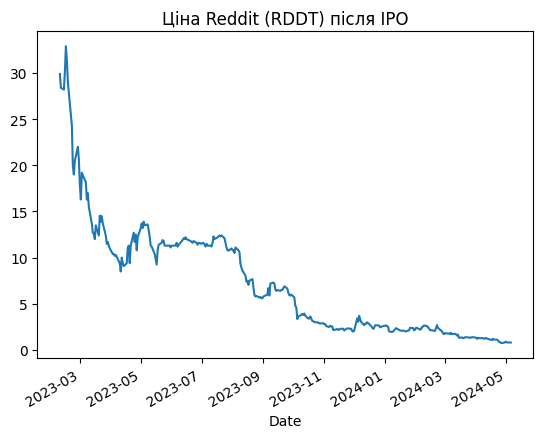

In [207]:
reddit['Adj Close'].plot.line(title=f'Ціна Stock (RDDT) після IPO')

### Питання 2: Стратегія інвестування "утримання кожної акції Х фіксованих днів після IPO(2023, 2024)" 

**Знайдіть оптимальну кількість днів X (від 1 до 30), де квантильне зростання на 75% є найвищим?**


Повторно використовуйте [фрагмент коду 1], щоб отримати список IPO за 2023 та 2024 роки (за URL-адресами: https://stockanalysis.com/ipos/2023/ та https://stockanalysis.com/ipos/2024/). 
Отримайте всі денні ціни OHLCV на всі акції з "датою IPO" до 1 березня 2024 року ("< 2024-03-01") - 184 тікери (без "RYZB"). Видаліть "RYZB", оскільки він більше не доступний у Фінансах Yahoo. 

Іноді може знадобитися змінити назву символу (наприклад, "IBAC" на stockanalysis.com -> "IBACU" у Yahoo Finance), щоб знайти ціни OHLCV для всіх акцій.
Деякі тікери, такі як «DYCQ» і «LEGT», були на ринку менше 30 днів (11 і 21 день відповідно). Залишимо їх у наборі даних; Це просто означає, що ви не могли утримувати їх більше днів, ніж вони були перераховані.

Припустимо, вам вдалося купити нову акцію (зареєстровану на IPO) в перший день за ціною [Adj Close]. Ваша стратегія полягає в тому, щоб утримувати рівно X повних днів (де X знаходиться від 1 до 30) і продавати за ціною "Adj. Close" протягом X днів (наприклад, якщо X = 1, ви продаєте наступного дня).
Знайдіть X, коли квантильне зростання на 75% (серед 185 інвестицій) є найвищим. 

Натяки:
* Ви можете згенерувати 30 додаткових стовпців: growth_future_1d ... growth_future_30d об'єднайте це з таблицею min_dates (перший день, коли кожна акція має дані про Yahoo Finance) і виконайте векторні операції з отриманим набором даних.
* Ви можете використовувати функцію 'DataFrame.describe()', щоб отримати середнє, мінімальне, максимальне, 25-50-75% квантилів.


Додаткові: 
* Ви також можете переконатися, що середня та 50-й процентиль (медіана) інвестиційна прибутковість є негативними для більшості значень X, маючи на увазі ставку для «щасливого» інвестора, який може бути в топ-25%.
* Що ви рекомендуєте: Чи пропонуєте ви використовувати цю стратегію для оптимального X?

In [217]:
ipo_df.isnull().sum()

IPO Date        0
Symbol          0
Company Name    0
IPO Price       0
Current         0
Return          0
dtype: int64

In [145]:
ipo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   IPO Date      218 non-null    datetime64[ns]
 1   Symbol        218 non-null    object        
 2   Company Name  218 non-null    object        
 3   IPO Price     218 non-null    object        
 4   Current       218 non-null    object        
 5   Return        218 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 10.3+ KB


In [146]:
ipo_df.head()

,IPO Date,Symbol,Company Name,IPO Price,Current,Return
0,2024-05-01,VIK,Viking Holdings Ltd.,$24.00,$28.94,18.04%
1,2024-04-26,ZONE,"CleanCore Solutions, Inc.",$4.00,$3.11,-21.50%
2,2024-04-25,RBRK,"Rubrik, Inc.",$32.00,$34.87,1.28%
3,2024-04-25,LOAR,Loar Holdings Inc.,$28.00,$51.10,77.59%
4,2024-04-25,MRX,Marex Group plc,$19.00,$19.14,0.84%


In [ ]:
symbols = ipo_filter['Symbol'].tolist()
symbols = list(reversed(symbols))

ipo_dates = ipo_filter['IPO Date'].tolist()
ipo_dates = list(reversed(ipo_dates))
start_date = ipo_dates[0]
end_date = ipo_dates[-1]

print(f"Стартовая дата отсчета IPO: {start_date.strftime('%Y-%m-%d')} для тикера {symbols[0]}")
print(f"Последняя дата отсчета IPO: {end_date.strftime('%Y-%m-%d')} для тикера {symbols[-1]}")

stocks_df = yf.download(" ".join(tickers), period="max", interval="1d") # End is excluded, need to add one day
stocks_df.info()

stocks_flt_df = stocks_df.query('index >= @start_date')
stocks_df.info()

stocks_flt_df = stocks_flt_df['Adj Close']
stocks_flt_df.shape

In [230]:
len(ipo_dates)

183

In [223]:
for i, ipo_date in enumerate(ipo_dates):
    # Перетворення дати IPO на формат YYYY-MM-DD
    ipo_date_str = ipo_date.strftime("%Y-%m-%d")

    # Порівняння дати IPO з 1 березня 2024 року
    if ipo_date_str < "2024-03-01":
        # Знаходження індексу дати IPO в масиві `ipo_dates`
        ipo_date_index = i

        # Отримання відповідного тикера з масиву `symbols`
        ticker = symbols[ipo_date_index]

        # Виведення дати IPO та тикера
        print(f"Дата IPO: {ipo_date_str}, тикер: {ticker}")

Дата IPO: 2023-01-13, тикер: MGOL
Дата IPO: 2023-01-13, тикер: ISRL
Дата IPO: 2023-01-13, тикер: SKWD
Дата IPO: 2023-01-20, тикер: CVKD
Дата IPO: 2023-01-25, тикер: QSG
Дата IPO: 2023-01-26, тикер: GNLX
Дата IPO: 2023-01-27, тикер: BREA
Дата IPO: 2023-01-27, тикер: TXO
Дата IPO: 2023-02-01, тикер: CETU
Дата IPO: 2023-02-03, тикер: ASST
Дата IPO: 2023-02-03, тикер: GPCR
Дата IPO: 2023-02-06, тикер: LICN
Дата IPO: 2023-02-09, тикер: LSDI
Дата IPO: 2023-02-09, тикер: HSAI
Дата IPO: 2023-02-09, тикер: NXT
Дата IPO: 2023-02-10, тикер: BLAC
Дата IPO: 2023-02-10, тикер: MLYS
Дата IPO: 2023-02-10, тикер: ENLT
Дата IPO: 2023-02-14, тикер: BFRG
Дата IPO: 2023-02-14, тикер: MARX
Дата IPO: 2023-02-15, тикер: GXAI
Дата IPO: 2023-02-15, тикер: DIST
Дата IPO: 2023-02-28, тикер: BMR
Дата IPO: 2023-02-28, тикер: SBXC
Дата IPO: 2023-03-09, тикер: AIXI
Дата IPO: 2023-03-09, тикер: AESI
Дата IPO: 2023-03-15, тикер: IZM
Дата IPO: 2023-03-16, тикер: ICG
Дата IPO: 2023-03-17, тикер: FORL
Дата IPO: 2023-03-21

In [228]:
len(symbols)

183

In [56]:
symbols

['MGOL',
 'ISRL',
 'SKWD',
 'CVKD',
 'QSG',
 'GNLX',
 'BREA',
 'TXO',
 'CETU',
 'ASST',
 'GPCR',
 'LICN',
 'LSDI',
 'HSAI',
 'NXT',
 'BLAC',
 'MLYS',
 'ENLT',
 'BFRG',
 'MARX',
 'GXAI',
 'DIST',
 'BMR',
 'SBXC',
 'AIXI',
 'AESI',
 'IZM',
 'ICG',
 'FORL',
 'MGRX',
 'OMH',
 'BANL',
 'OAKU',
 'YGFGF',
 'TMTC',
 'ZJYL',
 'HLP',
 'TBMC',
 'CHSN',
 'HKIT',
 'SYT',
 'SFWL',
 'HSHP',
 'MWG',
 'MGIH',
 'ISPR',
 'ARBB',
 'GDHG',
 'VCIG',
 'GDTC',
 'TCJH',
 'TPET',
 'WLGS',
 'UCAR',
 'USGO',
 'JYD',
 'AACT',
 'TRNR',
 'GODN',
 'KVUE',
 'ALCY',
 'SLRN',
 'SGE',
 'CWD',
 'IPXX',
 'ATS',
 'ATMU',
 'ESHA',
 'CAVA',
 'AZTR',
 'BOF',
 'BUJA',
 'GENK',
 'FIHL',
 'KGS',
 'SVV',
 'INTS',
 'VTMX',
 'PWM',
 'SXTP',
 'BOWN',
 'SGMT',
 'NETD',
 'APGE',
 'ODD',
 'TSBX',
 'WRNT',
 'ELWS',
 'JNVR',
 'KVAC',
 'HYAC',
 'PRZO',
 'SRFM',
 'HRYU',
 'CTNT',
 'PXDT',
 'MIRA',
 'FTEL',
 'NRXS',
 'LQR',
 'SPGC',
 'SRM',
 'NNAG',
 'IVP',
 'SWIN',
 'NWGL',
 'SPPL',
 'ARM',
 'NMRA',
 'DTCK',
 'CART',
 'KVYO',
 'MDBH',
 'TUR

In [6]:
tickers = ['MGOL', 'ISRL', 'SKWD', 'CVKD', 'QSG', 'GNLX', 'BREA', 'TXO', 'CETU', 'ASST', 'GPCR', 'LICN', 'LSDI', 'HSAI', 'NXT', 'BLAC', 'MLYS', 'ENLT', 'BFRG', 'MARX', 'GXAI', 'DIST', 'BMR', 'SBXC', 'AIXI', 'AESI', 'IZM', 'ICG', 'FORL', 'MGRX', 'OMH', 'BANL', 'OAKU', 'YGFGF', 'TMTC', 'ZJYL', 'HLP', 'TBMC', 'CHSN', 'HKIT', 'SYT', 'SFWL', 'HSHP', 'MWG', 'MGIH', 'ISPR', 'ARBB', 'GDHG', 'VCIG', 'GDTC', 'TCJH', 'TPET', 'WLGS', 'UCAR', 'USGO', 'JYD', 'AACT', 'TRNR', 'GODN', 'KVUE', 'ALCY', 'SLRN', 'SGE', 'CWD', 'IPXX', 'ATS', 'ATMU', 'ESHA', 'CAVA', 'AZTR', 'BOF', 'BUJA', 'GENK', 'FIHL', 'KGS', 'SVV', 'INTS', 'VTMX', 'PWM', 'SXTP', 'BOWN', 'SGMT', 'NETD', 'APGE', 'ODD', 'TSBX', 'WRNT', 'ELWS', 'JNVR', 'KVAC', 'HYAC', 'PRZO', 'SRFM', 'HRYU', 'CTNT', 'PXDT', 'MIRA', 'FTEL', 'NRXS', 'LQR', 'SPGC', 'SRM', 'NNAG', 'IVP', 'SWIN', 'NWGL', 'SPPL', 'ARM', 'NMRA', 'DTCK', 'CART', 'KVYO', 'MDBH', 'TURB', 'LRE', 'VSME', 'SYRA', 'ANL', 'MSS', 'QETA', 'SPKL', 'GPAK', 'LRHC', 'PMEC', 'GMM', 'BIRK', 'NCL', 'WBUY', 'MNR', 'ATGL', 'PAPL', 'LXEO', 'GVH', 'AITR', 'ANSC', 'CRGX', 'HG', 'SGN', 'GLAC', 'SHIM', 'DDC', 'RR', 'ELAB', 'CLBR', 'FEBO', 'GSIW', 'AFJK', 'INHD', 'BAYA', 'ZKH', 'LGCB', 'IROH', 'ROMA', 'SDHC', 'SYNX', 'CCTG', 'PSBD', 'JVSA', 'KSPI', 'JL', 'SUGP', 'YIBO', 'CGON', 'HAO', 'AVBP', 'BTSG', 'FBLG', 'AS', 'GUTS', 'ANRO', 'LEGT', 'AHR', 'PMNT', 'KYTX', 'TELO', 'HLXB', 'MGX', 'TBBB', 'UMAC', 'CHRO', 'DYCQ', 'VHAI', 'SMXT']


In [11]:
index_aes = tickers.index('AESI')
print("Индекс символа 'AESI':", index_aes)


Индекс символа 'AESI': 25


In [168]:
stocks_flt_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 329 entries, 2023-01-13 to 2024-05-06
Columns: 183 entries, AACT to ZKH
dtypes: float64(183)
memory usage: 472.9 KB


In [154]:
stocks_flt_df

Ticker,AACT,AESI,AFJK,AHR,AITR,AIXI,ALCY,ANL,ANRO,ANSC,...,VHAI,VSME,VTMX,WBUY,WLGS,WRNT,YGFGF,YIBO,ZJYL,ZKH
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-30,10.62,22.209999,10.260,13.73,10.31,1.22,10.64,13.80,15.51,10.235,...,0.1640,0.4100,35.509998,0.3790,0.547,0.300,0.002,2.08,3.81,11.50
2024-05-01,10.61,21.969999,10.275,13.88,10.31,1.22,10.64,14.13,16.10,10.225,...,0.1690,0.4130,36.000000,0.3720,0.535,0.324,0.002,2.06,3.63,11.96
2024-05-02,10.63,21.940001,10.275,13.97,10.31,1.25,10.70,13.02,14.40,10.235,...,0.1630,0.4000,35.930000,0.3740,0.580,0.318,0.002,2.10,3.52,12.05


In [3]:
stocks_flt_df.to_parquet("stocks_df_start_ipo_2023_2024.parquet")

NameError: name 'stocks_flt_df' is not defined

In [28]:
stocks_flt_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 328 entries, 2023-01-13 to 2024-05-03
Columns: 183 entries, AACT to ZKH
dtypes: float64(183)
memory usage: 471.5 KB


In [157]:
stocks_flt_df.describe()

Ticker,AACT,AESI,AFJK,AHR,AITR,AIXI,ALCY,ANL,ANRO,ANSC,...,growth_future_21d,growth_future_22d,growth_future_23d,growth_future_24d,growth_future_25d,growth_future_26d,growth_future_27d,growth_future_28d,growth_future_29d,growth_future_30d
count,226.000000,292.000000,72.000000,62.000000,86.000000,292.000000,210.000000,151.000000,65.000000,86.000000,...,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,10.369057,18.664294,10.211778,13.567210,10.252291,3.517175,10.421252,9.669576,15.092000,10.156209,...,50.064576,799.479070,276.270536,-134.603570,-3.868686,194.817163,302.494020,-303.519060,741.149937,-73.293814
std,0.156381,2.463967,0.043110,0.392544,0.044978,1.970694,0.134020,1.681211,1.737746,0.041132,...,2280.675123,12634.629001,3677.562585,4160.725644,2722.959150,6162.063105,4331.202413,3721.345922,9045.934932,2090.548977
min,10.100000,15.115661,10.154000,12.834673,10.140000,1.200000,10.180000,7.111000,12.960000,10.070000,...,-11717.363146,-3808.477369,-5924.694531,-61801.759636,-14256.834515,-42161.817876,-13495.905270,-58900.300868,-13626.596704,-23208.677813
25%,10.230000,16.790874,10.180000,13.316218,10.210000,1.920000,10.320000,8.667500,14.130000,10.130000,...,-93.977748,-94.138946,-92.657630,-83.121423,-77.421199,-85.325151,-109.314907,-99.923532,-90.226790,-143.849545
50%,10.360000,17.414480,10.190000,13.566819,10.255000,2.285000,10.410000,9.130000,14.520000,10.150000,...,-17.356681,-25.191293,-17.756712,-10.657847,-9.794187,-9.336026,-12.513959,-23.654000,-9.492890,-27.033743
75%,10.510000,20.844786,10.260000,13.730000,10.290000,5.498500,10.550750,10.560000,15.560000,10.181250,...,41.870365,28.302875,45.686925,55.872515,57.592444,62.598945,61.746019,42.503908,72.836986,56.954538
max,10.630000,23.840000,10.300000,14.750000,10.320000,10.040000,10.700000,15.000000,21.799999,10.235000,...,31474.485314,225925.603293,60355.291999,32019.330023,37670.832447,102381.998724,63050.653880,11701.645536,113605.838850,9989.052702


In [186]:
# Создание DataFrame для хранения результатов
# result_df = pd.DataFrame()


# Визначення увеличення ціни акції в кожний наступний X днів після покупки
for i in range(1, 31):
      stocks_flt_df[f"growth_future_{i}d"] = stocks_flt_df.shift(-i).div(stocks_flt_df).sum(axis=1)

# Знаходження оптимального значення X
mean_growth = {}
for i in range(1, 31):
    mean_growth[i] = stocks_flt_df[[f"growth_future_{i}d" for i in range(1, i + 1)]].mean(axis=1).mean()

optimal_X = max(mean_growth, key=mean_growth.get)
print("Оптимальне значення X:", optimal_X)

# Збереження результатів
# result_df.to_csv("result.csv")

# Объединение с таблицей min_dates
# Предположим, что у вас есть таблица min_dates, которая содержит первый день для каждого тикера
# Вам нужно добавить код для загрузки или создания этой таблицы

# result_df = pd.merge(result_df, min_dates, left_index=True, right_index=True)

# Сохранение результатов
# result_df.to_csv("result.csv")

Оптимальне значення X: 4


In [159]:
ipo_dates

[Timestamp('2023-01-13 00:00:00'),
 Timestamp('2023-01-13 00:00:00'),
 Timestamp('2023-01-13 00:00:00'),
 Timestamp('2023-01-20 00:00:00'),
 Timestamp('2023-01-25 00:00:00'),
 Timestamp('2023-01-26 00:00:00'),
 Timestamp('2023-01-27 00:00:00'),
 Timestamp('2023-01-27 00:00:00'),
 Timestamp('2023-02-01 00:00:00'),
 Timestamp('2023-02-03 00:00:00'),
 Timestamp('2023-02-03 00:00:00'),
 Timestamp('2023-02-06 00:00:00'),
 Timestamp('2023-02-09 00:00:00'),
 Timestamp('2023-02-09 00:00:00'),
 Timestamp('2023-02-09 00:00:00'),
 Timestamp('2023-02-10 00:00:00'),
 Timestamp('2023-02-10 00:00:00'),
 Timestamp('2023-02-10 00:00:00'),
 Timestamp('2023-02-14 00:00:00'),
 Timestamp('2023-02-14 00:00:00'),
 Timestamp('2023-02-15 00:00:00'),
 Timestamp('2023-02-15 00:00:00'),
 Timestamp('2023-02-28 00:00:00'),
 Timestamp('2023-02-28 00:00:00'),
 Timestamp('2023-03-09 00:00:00'),
 Timestamp('2023-03-09 00:00:00'),
 Timestamp('2023-03-15 00:00:00'),
 Timestamp('2023-03-16 00:00:00'),
 Timestamp('2023-03-

In [170]:
ipo_dates_index = [entry['ipo_date'] for entry in ipo_dates]
stocks_flt_df_183 = stocks_flt_df.drop(tickers, axis=1).loc[ipo_dates_index]

In [173]:
stocks_flt_df_183.shape

(183, 30)

In [171]:
quartiles_75 = stocks_flt_df_183.describe().loc["75%"]
quartiles_75.sort_values(ascending=True)

Ticker
growth_future_1d     138.116966
growth_future_2d     140.184701
growth_future_3d     142.270740
growth_future_4d     144.115451
growth_future_5d     145.559633
growth_future_6d     145.780791
growth_future_7d     147.318895
growth_future_8d     148.769069
growth_future_9d     149.386258
growth_future_10d    150.368676
growth_future_11d    151.700919
growth_future_12d    152.125498
growth_future_13d    154.120380
growth_future_14d    155.008802
growth_future_15d    157.038559
growth_future_16d    159.195278
growth_future_18d    160.171818
growth_future_17d    160.239177
growth_future_19d    160.990869
growth_future_20d    162.623987
growth_future_22d    163.087511
growth_future_21d    163.907271
growth_future_23d    165.614998
growth_future_25d    167.431266
growth_future_24d    167.676149
growth_future_26d    168.230191
growth_future_27d    168.609168
growth_future_28d    169.328121
growth_future_29d    169.418762
growth_future_30d    169.722506
Name: 75%, dtype: float64

In [218]:
# Загрузка данных
df = pd.read_parquet("stocks_df_start_ipo_2023_2024.parquet")

In [219]:
df.isnull().sum()

Ticker
AACT     103
AESI      37
AFJK     257
AHR      267
AITR     242
        ... 
WRNT     131
YGFGF     51
YIBO     258
ZJYL      50
ZKH      232
Length: 183, dtype: int64

In [172]:
quartiles_25 = stocks_flt_df_183.describe().loc["25%"]
quartiles_25.sort_values(ascending=True)

Ticker
growth_future_1d     46.882644
growth_future_2d     47.740767
growth_future_3d     49.512376
growth_future_4d     50.531703
growth_future_5d     52.016146
growth_future_6d     52.871369
growth_future_7d     53.804434
growth_future_8d     55.325421
growth_future_9d     56.000885
growth_future_10d    57.669529
growth_future_11d    58.895808
growth_future_12d    60.233456
growth_future_13d    61.358907
growth_future_14d    63.706607
growth_future_15d    64.088597
growth_future_17d    66.822891
growth_future_16d    67.126249
growth_future_18d    67.983452
growth_future_19d    68.767378
growth_future_20d    70.389100
growth_future_21d    72.249619
growth_future_22d    73.805858
growth_future_23d    74.331724
growth_future_24d    74.426850
growth_future_25d    75.768145
growth_future_26d    77.805931
growth_future_27d    78.862079
growth_future_28d    81.516548
growth_future_29d    81.878463
growth_future_30d    83.751236
Name: 25%, dtype: float64

In [174]:
quartiles_50 = stocks_flt_df_183.describe().loc["50%"]
quartiles_50.sort_values(ascending=True)

Ticker
growth_future_5d      91.208402
growth_future_2d      91.644183
growth_future_4d      91.703090
growth_future_1d      92.196745
growth_future_3d      92.537638
growth_future_6d      92.852996
growth_future_7d      93.630040
growth_future_8d      95.146355
growth_future_11d     97.907763
growth_future_9d      97.976192
growth_future_10d     98.436122
growth_future_12d     98.477089
growth_future_13d     99.463609
growth_future_14d    101.379831
growth_future_15d    101.761549
growth_future_19d    103.201838
growth_future_18d    103.202249
growth_future_20d    103.639183
growth_future_16d    103.659606
growth_future_17d    103.707488
growth_future_21d    105.458789
growth_future_22d    106.554987
growth_future_23d    107.509642
growth_future_27d    108.207826
growth_future_24d    108.327523
growth_future_28d    109.016278
growth_future_29d    109.865469
growth_future_25d    110.217913
growth_future_30d    110.412607
growth_future_26d    111.857643
Name: 50%, dtype: float64

In [69]:
df.head(105)

Ticker,AACT,AESI,AFJK,AHR,AITR,AIXI,ALCY,ANL,ANRO,ANSC,...,VHAI,VSME,VTMX,WBUY,WLGS,WRNT,YGFGF,YIBO,ZJYL,ZKH
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-08,NaN,17.439655,NaN,NaN,NaN,5.60,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.81,NaN,3.498,NaN,0.4120,NaN
2023-06-09,NaN,17.023273,NaN,NaN,NaN,5.59,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.75,NaN,3.310,NaN,0.4265,NaN
2023-06-12,NaN,16.742458,NaN,NaN,NaN,5.55,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.75,NaN,3.410,NaN,0.6600,NaN


In [220]:
# Припустимо, df - це ваш DataFrame з даними про акції

tickers_up = []
ipo_dates = []
i=0
for column in df.columns:
    # Шукаємо перший непорожній рядок у стовпці
    ipo_date = df[column].first_valid_index()
    ipo_dates.append({'ticker': column, 'ipo_date': ipo_date})
    for offset in range(1, 5):
        next_day = ipo_date + pd.DateOffset(days=offset)
        # print(next_day)
        # Перевірка, чи next_day є дійсним індексом
        if next_day in df.index:
            if df.loc[next_day, column] > df.loc[ipo_date, column]:
                tickers_up.append(column)
                # Додаємо дату IPO та назву акції до списку
                # ipo_dates.append({'ticker': column, 'ipo_date': ipo_date})
                break

# Виведемо перші кілька елементів масиву об'єктів
len(tickers_up)


103

In [221]:
max_ipo_date = max(ipo_dates, key=lambda x: x['ipo_date'])
ticker_with_max_ipo_date = max_ipo_date['ticker']

print("Найбільша дата IPO:", max_ipo_date['ipo_date'])
print("Тікер акції з найбільшою датою IPO:", ticker_with_max_ipo_date)

Найбільша дата IPO: 2024-04-12 00:00:00
Тікер акції з найбільшою датою IPO: DYCQ


In [116]:
tickers_up

['AFJK',
 'AITR',
 'AIXI',
 'ANRO',
 'ANSC',
 'ARBB',
 'AS',
 'ATGL',
 'ATMU',
 'ATS',
 'AVBP',
 'AZTR',
 'BANL',
 'BAYA',
 'BLAC',
 'BMR',
 'BOF',
 'BOWN',
 'BTSG',
 'BUJA',
 'CAVA',
 'CCTG',
 'CETU',
 'CRGX',
 'DDC',
 'DYCQ',
 'ELAB',
 'ESHA',
 'FEBO',
 'FIHL',
 'FORL',
 'FTEL',
 'GENK',
 'GLAC',
 'GMM',
 'GODN',
 'GXAI',
 'HAO',
 'HG',
 'HKIT',
 'HLP',
 'HLXB',
 'HSAI',
 'HSHP',
 'HYAC',
 'ICG',
 'INTS',
 'IPXX',
 'IROH',
 'IVP',
 'JL',
 'JVSA',
 'KGS',
 'KVAC',
 'KVYO',
 'LEGT',
 'LICN',
 'LXEO',
 'MGOL',
 'MGX',
 'MIRA',
 'MLYS',
 'MNR',
 'NCL',
 'NETD',
 'NNAG',
 'NRXS',
 'NXT',
 'OAKU',
 'ODD',
 'OMH',
 'PMNT',
 'PSBD',
 'PWM',
 'PXDT',
 'QSG',
 'ROMA',
 'RR',
 'SDHC',
 'SFWL',
 'SGE',
 'SGMT',
 'SHIM',
 'SKWD',
 'SLRN',
 'SPKL',
 'SVV',
 'SYNX',
 'SYRA',
 'SYT',
 'TBBB',
 'TBMC',
 'TELO',
 'TMTC',
 'TPET',
 'TRNR',
 'TSBX',
 'TXO',
 'UMAC',
 'USGO',
 'VHAI',
 'VTMX',
 'WLGS']

In [90]:
# Перевірка на унікальність елементів у масиві tickers_up
if len(tickers_up) == len(set(tickers_up)):
    print("Елементи масиву tickers_up є унікальними.")
else:
    print("Елементи масиву tickers_up не є унікальними.")

Елементи масиву tickers_up є унікальними.


In [91]:
index_aes = tickers_up.index('MGOL')
print("Индекс символа 'MGOL':", index_aes)

Индекс символа 'MGOL': 60


In [97]:
# Знайдемо тікери, які є в ticker, але немає у tickers_up
missing_tickers = [ticker for ticker in tickers if ticker not in tickers_up]

In [126]:
# Вибираємо тільки тікери, які не містяться у списку missing_tickers
stocks_up_df = df.loc[:, ~df.columns.isin(missing_tickers)]

In [99]:
stocks_up_df.shape

(328, 103)

In [135]:
ipo_dates

[{'ticker': 'AFJK', 'ipo_date': Timestamp('2024-01-23 00:00:00')},
 {'ticker': 'AITR', 'ipo_date': Timestamp('2024-01-02 00:00:00')},
 {'ticker': 'AIXI', 'ipo_date': Timestamp('2023-03-09 00:00:00')},
 {'ticker': 'ANRO', 'ipo_date': Timestamp('2024-02-02 00:00:00')},
 {'ticker': 'ANSC', 'ipo_date': Timestamp('2024-01-03 00:00:00')},
 {'ticker': 'ARBB', 'ipo_date': Timestamp('2023-04-05 00:00:00')},
 {'ticker': 'AS', 'ipo_date': Timestamp('2024-02-01 00:00:00')},
 {'ticker': 'ATGL', 'ipo_date': Timestamp('2023-10-31 00:00:00')},
 {'ticker': 'ATMU', 'ipo_date': Timestamp('2023-05-26 00:00:00')},
 {'ticker': 'ATS', 'ipo_date': Timestamp('2023-01-13 00:00:00')},
 {'ticker': 'AVBP', 'ipo_date': Timestamp('2024-01-26 00:00:00')},
 {'ticker': 'AZTR', 'ipo_date': Timestamp('2023-06-20 00:00:00')},
 {'ticker': 'BANL', 'ipo_date': Timestamp('2023-03-23 00:00:00')},
 {'ticker': 'BAYA', 'ipo_date': Timestamp('2023-12-29 00:00:00')},
 {'ticker': 'BLAC', 'ipo_date': Timestamp('2023-03-21 00:00:00')}

In [ ]:
ipo_dates_index = [entry['ipo_date'] for entry in ipo_dates]
stocks_up_df_filtered = stocks_up_df.drop(tickers_up, axis=1).loc[ipo_dates_index]

In [139]:
quartiles_75 = stocks_up_df_filtered.describe().loc["75%"]
quartiles_75.sort_values(ascending=True)

Ticker
growth_future_1d       0.280354
growth_future_2d       0.550212
growth_future_6d       0.787671
growth_future_3d       2.050857
growth_future_4d       3.142720
growth_future_5d       3.280015
growth_future_7d       4.256433
growth_future_14d      6.600907
growth_future_12d     11.168224
growth_future_11d     16.541265
growth_future_8d      16.691715
growth_future_9d      19.261926
growth_future_10d     22.503245
growth_future_30d     26.351403
growth_future_24d     28.999020
growth_future_16d     29.080002
growth_future_27d     34.427180
growth_future_13d     48.260471
growth_future_15d     56.471359
growth_future_20d     57.720624
growth_future_23d     61.630058
growth_future_25d     64.937680
growth_future_19d     74.392684
growth_future_17d     78.841041
growth_future_22d     90.555602
growth_future_18d    111.243410
growth_future_29d    129.419559
growth_future_28d    133.188305
growth_future_26d    245.344626
growth_future_21d    246.108935
Name: 75%, dtype: float64

In [134]:
stocks_up_df.drop(tickers_up, axis=1)

Ticker,growth_future_1d,growth_future_2d,growth_future_3d,growth_future_4d,growth_future_5d,growth_future_6d,growth_future_7d,growth_future_8d,growth_future_9d,growth_future_10d,...,growth_future_21d,growth_future_22d,growth_future_23d,growth_future_24d,growth_future_25d,growth_future_26d,growth_future_27d,growth_future_28d,growth_future_29d,growth_future_30d
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-13,0.097857,-0.718875,-3.054567,-16.319367,-4.298260,-4.521809,27.220697,2.857227,-12.670026,16.314293,...,-1737.405884,44.254047,1739.436554,-1690.021586,1767.596098,-1772.574952,-718.765360,1699.633711,-11324.868647,70.008972
2023-01-17,-0.256053,-0.715416,-1.361639,-2.400178,-5.280844,13.221286,10.969860,-246.602840,-8.165185,3.483614,...,-541.335328,-3196.368985,-1639.045096,8188.372924,-2752.168091,1207.913573,4485.947440,3748.905973,-410.651656,-2525.813142
2023-01-18,0.044296,-2.232835,-4.188482,-4.803214,-0.401728,13.672786,-484.505873,-5.308025,9.303337,1.046111,...,1266.797126,418.118906,27756.328822,1534.186843,735.889080,3846.807337,3390.406458,-2009.335234,2210.323768,1412.129295
2023-01-19,-0.130882,-0.303932,0.082766,152.242274,-143.489640,5.433307,-53.967995,-62.954244,-131.873507,-236.018604,...,252.841196,-112.564173,65.708600,-4614.377265,-946.214860,8687.079654,1068.636588,-137.421134,3137.368933,-170.951021
2023-01-20,-0.050437,-0.553570,40.695449,4.339147,129.381064,-6.841131,-6.631592,-10.415562,1.912361,-8.924506,...,-2758.965764,10884.096634,-619.680906,-6286.464344,-6620.878764,11143.800833,10900.689400,1131.287731,876.075982,-1015.119351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29,-1.430556,-1.310018,-2.136968,-2.389734,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-04-30,1.635767,1.160359,0.257797,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-05-01,0.232482,-0.308305,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [185]:
# Создание DataFrame для хранения результатов
# result_df = pd.DataFrame()


# Визначення увеличення ціни акції в кожний наступний X днів після покупки
for i in range(1, 31):
  # Use .loc for assignment, but be aware of potential performance issues
  stocks_flt_df[f"growth_future_{i}d"]= (
      stocks_flt_df.shift(-i).div(stocks_flt_df) - 1
  ).sum(axis=1)

# Знаходження оптимального значення X
mean_growth = {}
for i in range(1, 31):
    mean_growth[i] = stocks_up_df[[f"growth_future_{i}d" for i in range(1, i + 1)]].mean(axis=1).mean()

optimal_X = max(mean_growth, key=mean_growth.get)
print("Оптимальне значення X:", optimal_X)

# Збереження результатів
# result_df.to_csv("result.csv")

# Объединение с таблицей min_dates
# Предположим, что у вас есть таблица min_dates, которая содержит первый день для каждого тикера
# Вам нужно добавить код для загрузки или создания этой таблицы

# result_df = pd.merge(result_df, min_dates, left_index=True, right_index=True)

# Сохранение результатов
# result_df.to_csv("result.csv")

Оптимальне значення X: 16


In [ ]:
def is_symbol_available(symbol):
    try:
        data = yf.download(symbol, period="1d")
        if data.empty:
            return False
        else:
            return True
    except Exception:
        return False

In [ ]:
# Функція для отримання OHLCV даних з урахуванням перевірок
# def get_ohlcv_data(symbol, start_date, end_date='2024-03-01'):
#     try:
#         # Перевірити, чи символ доступний
#         if not is_symbol_available(symbol):
#             print(f"Символ {symbol} недоступний на Yahoo Finance. Пропущено.")
#             return None

#         # Завантажити дані OHLCV
#         data = yf.download(symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date)

#         data['Adj Close'] = data['Adj Close'].ffill()  # Заповнення пропущених значень

#         return data[['Adj Close']]
#     except Exception as e:
#         print(f"Помилка при завантаженні даних для {symbol}: {e}")
#         return None


# Словник для зберігання даних про зростання
growth_data = {}

# Розрахунок зростання для різних значень X
for X in range(1, 31):
    # Стовпчик з датою X-го дня після IPO
    future_X_dates = [ipo_date + pd.DateOffset(days=X) for ipo_date in ipo_dates]
    # Словник для тимчасових даних
    temp_growth_data = {}

    # Завантаження та обробка OHLCV даних
    for i, (symbol, ipo_date) in enumerate(zip(symbols, ipo_dates)):
        # Спробуйте отримати дані OHLCV
        ohlcv_data = get_ohlcv_data(symbol, ipo_date)

        # Перевірте, чи дані OHLCV успішно завантажені
        if ohlcv_data is not None:
            # Розрахуйте зростання для кожного дня
            ohlcv_data = ohlcv_data.assign(growth=ohlcv_data['Adj Close'] - ohlcv_data['Adj Close'].iloc[0])

            print(ohlcv_data)

            # Збережіть дані зростання в тимчасовому словнику
            temp_growth_data[symbol] = ohlcv_data

        # Виведення інформації про хід виконання
        if i % 10 == 0:
            print(f"Оброблено {i + 1} з {len(symbols)} IPO...")

    # Об'єднання тимчасових даних в один DataFrame
    growth_df = pd.DataFrame()
    for symbol, data in temp_growth_data.items():
        growth_df = pd.concat(temp_growth_data)

# Обчислення квантильного зростання на 75%
growth_df_75q = growth_df.groupby('IPO Date')['growth'].quantile(0.75)

# Знаходження оптимального X
optimal_X = growth_df_75q.idxmax()
optimal_75q_growth = growth_df_75q.max()

# Виведення результатів
print(f"Оптимальне значення X: {optimal_X} днів")
print(f"75-й квантиль зростання для X = {optimal_X}: {optimal_75q_growth:.2f}%")

# Додатковий аналіз (за бажанням)
# -  Можна дослідити розподіл зростання для різних значень X.
# -  Можна проаналізувати вплив факторів, таких як галузь, розмір компанії, на результативність стратегії.
# -  Можна протестувати цю стратегію на історичних даних, щоб оцінити її довгострокову ефективність.


**Важливо зазначити:**

- Ця стратегія ґрунтується на історичних даних і не гарантує успіху в майбутньому.
- Інвестування завжди пов'язане з ризиком, і ви можете втратити гроші.
- Перед прийняттям будь-яких інвестиційних рішень важливо провести власне дослідження та проконсультуватися з фінансовим радником.


### Question 3: Is Growth Concentrated in the Largest Stocks?

**Get the share of days (percentage as int) when Large Stocks outperform (growth_7d - growth over 7 periods back) the Largest stocks?**

1. **Data Retrieval and Processing**
   - Reuse [Code Snippet 5] to obtain OHLCV stats for 33 stocks for 10 full years of data (2014-01-01 to 2023-12-31).
   - Download slightly more data (7 periods before 2014-01-01 to calculate the growth_7d for the first 6 days correctly).

2. **Defining Stock Lists**
   - Define the following stock lists:
     - `US_STOCKS`: ['MSFT', 'AAPL', 'GOOG', 'NVDA', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO','V', 'JPM']
     - `EU_STOCKS`: ['NVO','MC.PA', 'ASML', 'RMS.PA', 'OR.PA', 'SAP', 'ACN', 'TTE', 'SIE.DE','IDEXY','CDI.PA']
     - `INDIA_STOCKS`: ['RELIANCE.NS','TCS.NS','HDB','BHARTIARTL.NS','IBN','SBIN.NS','LICI.NS','INFY','ITC.NS','HINDUNILVR.NS','LT.NS']
     - `LARGEST_STOCKS`: US_STOCKS + EU_STOCKS + INDIA_STOCKS
     - `NEW_US`: ['TSLA','WMT','XOM','UNH','MA','PG','JNJ','MRK','HD','COST','ORCL']
     - `NEW_EU`: ['PRX.AS','CDI.PA','AIR.PA','SU.PA','ETN','SNY','BUD','DTE.DE','ALV.DE','MDT','AI.PA','EL.PA']
     - `NEW_INDIA`: ['BAJFINANCE.NS','MARUTI.NS','HCLTECH.NS','TATAMOTORS.NS','SUNPHARMA.NS','ONGC.NS','ADANIENT.NS','ADANIENT.NS','NTPC.NS','KOTAKBANK.NS','TITAN.NS']
     - `LARGE_STOCKS`: NEW_EU + NE

    For example, for the first of data you should have:
    | Date   |      ticker_category      |  growth_7d |
    |----------|:-------------:|------:|
    | 2014-01-01 |  LARGE | 1.011684 |
    | 2014-01-01 |   LARGEST   |   1.011797 |
    
    On that day, the LARGEST group was growing faster than LARGE one (new stocks).
W_US + NEW_INDIA

3. **Calculating Growth_7d**
   - Calculate `growth_7d` for every stock and every day.
   - Get the average daily `growth_7d` for the `LARGEST_STOCKS` group vs. the `LARGE_STOCKS` group.

4. **Analyzing Results**
   - Calculate the number of days when the `LARGE_STOCKS` group outperforms the `LARGEST_STOCKS` group.
   - Divide it by the total number of trading days (2595 days).
   - Convert it to a percentage (closest INTEGER value).
   - Use the result to determine whether to consider expanding the dataset with more st
  
     For example, if you find that 1700 out of 2595 days meet this condition, it means that 1700/2595 = 0.655, or approximately 66% of days, the LARGE stocks were growing faster than the LARGEST ones. This suggests that you should consider extending your dataset with more stocks to seek higher growth.

HINT: you can use pandas.pivot_table() to "flatten" the table (LARGE and LARGEST growth_7d as columns)ocks to seek higher growth.

## Питання 3: Чи зосереджено зростання в Largest Stocks?

**Отримайте частку днів (у відсотках як int), коли Large Stocks перевершують (growth_7d - зростання за 7 періодів назад) Largest Stocks?**

### Отримання даних та розрахунок growth_7d

Повторно використовуйте [Фрагмент коду 5], щоб отримати статистику OHLCV для 33 акцій за 10 років даних (з 01.01.2014 по 31.12.2023):

- `US_STOCKS = ['MSFT', 'AAPL', 'GOOG', 'NVDA', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO','V', 'JPM']`
- `EU_STOCKS = ['NVO','MC.PA', 'ASML', 'RMS.PA', 'OR.PA', 'SAP', 'ACN', 'TTE', 'SIE.DE','IDEXY','CDI.PA']`
- `INDIA_STOCKS = ['RELIANCE.NS','TCS.NS','HDB','BHARTIARTL.NS','IBN','SBIN.NS','LICI.NS','INFY','ITC.NS','HINDUNILVR.NS','LT.NS']`
- `LARGEST_STOCKS = US_STOCKS + EU_STOCKS + INDIA_STOCKS`

Тепер додамо топ-12-22 акції (станом на кінець квітня 2024 року):

- `NEW_US = ['TSLA','WMT','XOM','UNH','MA','PG','JNJ','MRK','HD','COST','ORCL']`
- `NEW_EU = ['PRX.AS','CDI.PA','AIR.PA','SU.PA','ETN','SNY','BUD','DTE.DE','ALV.DE','MDT','AI.PA','EL.PA']`
- `NEW_INDIA = ['BAJFINANCE.NS','MARUTI.NS','HCLTECH.NS','TATAMOTORS.NS','SUNPHARMA.NS','ONGC.NS','ADANIENT.NS','ADANIENT.NS','NTPC.NS','KOTAKBANK.NS','TITAN.NS']`
- `LARGE_STOCKS = NEW_EU + NEW_US + NEW_INDIA`

Розрахуйте "growth_7d" для кожної акції та кожного дня.
Обчисліть середнє щоденне значення "growth_7d" для групи LARGEST_STOCKS і групи LARGE_STOCKS.

Наприклад, для першого з даних ви повинні мати:
| Дата       |      ticker_category |  growth_7d |
|------------|----------------------|------------|
| 2014-01-01 |  LARGE               | 1.011684   |
| 2014-01-01 |  LARGEST             | 1.011797   |

У цей день LARGEST група зростала швидше, ніж LARGE (нові акції).

### Визначення частки днів

Обчисліть кількість днів, коли LARGE (нові менші акції) перевершує LARGEST ГРУПУ, розділіть її на загальну кількість торгових днів (2595 днів) і переведіть її у відсоток (найближче ціле число). 

Наприклад, якщо ви виявите, що 1700 з 2595 днів відповідають цій умові, це означає, що 1700/2595 = 0,655, або приблизно 66% днів, LARGE акції зростали швидше, ніж LARGEST. 

Це говорить про те, що вам слід розглянути можливість розширення свого набору даних більшою кількістю акцій, щоб досягти більшого зростання.

ПІДКАЗКА: Ви можете використовувати pandas.pivot_table() для "зведення" таблиці (LARGE і LARGEST growth_7d як стовпці)

In [55]:
def get_historical_data(tickers, start_date, end_date):
    """
    Завантажує історичні дані OHLCV для заданих акцій за заданий часовий проміжок.

    Args:
        tickers (list): Список символів акцій.
        start_date (str): Дата початку в форматі YYYY-MM-DD.
        end_date (str): Дата закінчення в форматі YYYY-MM-DD.

    Returns:
        pandas.DataFrame: DataFrame з історичними даними Adj Close.
    """

    # Перевірте типи даних
    if not isinstance(tickers, list):
        raise TypeError("`tickers` must be a list of symbols.")
    if not isinstance(start_date, str) or not isinstance(end_date, str):
        raise TypeError("`start_date` and `end_date` must be strings in YYYY-MM-DD format.")

    # Завантажте дані для кожного символу

    data = {}
    for ticker in tickers:
        try:
        # Завантажте дані для символу
          data[ticker] = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)['Close']
        except KeyError:
          print(f"Попередження: 'Close' не знайдено для {ticker}. Пропущено...")
    return pd.DataFrame(data)



In [48]:
# Визначення списків акцій LARGEST_STOCKS
US_STOCKS = ['MSFT', 'AAPL', 'GOOG', 'NVDA', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO','V', 'JPM']
EU_STOCKS = ['NVO','MC.PA', 'ASML', 'RMS.PA', 'OR.PA', 'SAP', 'ACN', 'TTE', 'SIE.DE','IDEXY','CDI.PA']
INDIA_STOCKS = ['RELIANCE.NS','TCS.NS','HDB','BHARTIARTL.NS','IBN','SBIN.NS','LICI.NS','INFY','ITC.NS','HINDUNILVR.NS','LT.NS']
LARGEST_STOCKS = US_STOCKS + EU_STOCKS + INDIA_STOCKS

In [49]:
# Визначення списків акцій LARGE_STOCKS
NEW_US = ['TSLA','WMT','XOM','UNH','MA','PG','JNJ','MRK','HD','COST','ORCL']
NEW_EU = ['PRX.AS','CDI.PA','AIR.PA','SU.PA','ETN','SNY','BUD','DTE.DE','ALV.DE','MDT','AI.PA','EL.PA']
NEW_INDIA = ['BAJFINANCE.NS','MARUTI.NS','HCLTECH.NS','TATAMOTORS.NS','SUNPHARMA.NS','ONGC.NS','ADANIENT.NS','ADANIENT.NS','NTPC.NS','KOTAKBANK.NS','TITAN.NS']
LARGE_STOCKS = NEW_EU + NEW_US + NEW_INDIA

In [56]:
# Download OHLCV data
data = get_historical_data(LARGEST_STOCKS + LARGE_STOCKS, start_date='2014-01-01', end_date='2023-12-31') #period='max', interval='1d'

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%*******

In [67]:
data.tail(20)

,MSFT,AAPL,GOOG,NVDA,AMZN,META,BRK-B,LLY,AVGO,V,...,BAJFINANCE.NS,MARUTI.NS,HCLTECH.NS,TATAMOTORS.NS,SUNPHARMA.NS,ONGC.NS,ADANIENT.NS,NTPC.NS,KOTAKBANK.NS,TITAN.NS
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6526.019531,8324.958008,973.958740,393.573334,980.493164,NaN,3839.281738,158.847885,1823.548584,2557.464111
2023-01-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5985.466309,8301.973633,1024.790527,411.716797,1018.306580,NaN,3617.992432,156.909561,1783.331665,2398.080566
2023-02-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6340.458008,8612.601562,1054.863770,441.623596,975.370605,NaN,1620.640259,162.901489,1735.870728,2466.159668
2023-05-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6902.718750,9246.486328,1082.988647,519.829834,959.566895,NaN,2532.784668,171.051422,1951.593018,2803.167969
2023-06-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7354.947754,9443.135742,1093.903198,564.291260,992.610962,NaN,2400.200684,180.317123,1823.048950,2959.013184
2023-07-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7860.450195,9557.459961,1144.917603,589.612366,1039.179810,NaN,2386.507568,188.273010,1860.168335,3064.720459
2023-09-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7270.250000,10362.450195,1195.435791,609.000000,1102.614624,NaN,2470.600098,231.981293,1762.199951,3100.300049
2023-11-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7073.649902,10488.500000,1301.355713,679.950012,1192.005005,NaN,2175.250000,251.057983,1739.300049,3408.399902
2015-12-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Calculate growth_7d
for date in data.index:
    for ticker in data.columns:
        if pd.notna(data.loc[date, ticker, 'Close']):
            data.loc[date, ticker, 'LARGE_growth_7d'] = data.loc[date, ticker, 'Close'] / data.loc[date - pd.DateOffset(days=7), ticker, 'Close']
            data.loc[date, ticker, 'LARGEST_growth_7d'] = data.loc[date, ticker, 'Close'] / data.loc[date - pd.DateOffset(days=7), ticker, 'Close']

# Compare growth and identify outperform days
outperform_days = 0
total_days = len(data.index)  # Assuming all trading days are present

for date in data.index:
    if pd.notna(data.loc[date, 'LARGE_growth_7d']) and pd.notna(data.loc[date, 'LARGEST_growth_7d']):
        if data.loc[date, 'LARGE_growth_7d'] > data.loc[date, 'LARGEST_growth_7d']:
            outperform_days += 1

# Calculate percentage of outperform days
outperform_pct = int(outperform_days / total_days * 100)

# Print results
print(f"Large stocks outperformed largest stocks on approximately {outperform_pct}% of trading days during 2014-2023.")

In [ ]:
# Визначення списків акцій
LARGEST_STOCKS = ['MSFT', 'AAPL', 'GOOG', 'NVDA', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO', 'V', 'JPM', 'NVO', 'MC.PA',
                  'ASML', 'RMS.PA', 'ABB.PA', 'SAP', 'ACN', 'TTE', 'SIE.DE', 'IDEXY', 'CDI.PA', 'RELIANCE.NS', 'TCS.NS',
                  'HDB', 'BHARTIARTL.NS', 'IBN', 'SBIN.NS', 'LICI.NS', 'INFY', 'ITC.NS', 'HINDUNILVR.NS', 'LT.NS',
                  'TSLA', 'WMT', 'XOM', 'UNH', 'MA', 'PG', 'JNJ', 'MRK', 'HD', 'COST', 'ORCL', 'PRX.AS', 'CDI.PA',
                  'AIR.PA', 'SU.PA', 'ETN', 'SNI', 'BUD', 'DTE.DE', 'ALV.DE', 'MDT', 'AI.PA', 'EL.PA', 'BAJFINANCE.NS',
                  'MARUTI.NS', 'HCLTECH.NS', 'TATAMOTORS.NS', 'SUNPHARMA.NS', 'ONGC.NS', 'ADANIENT.NS', 'ADANIPOWER.NS',
                  'NTPC.NS', 'KOTAKBANK.NS', 'TITAN.NS']

# Видаліть 'ABB.PA' з LARGEST_STOCKS (якщо не критично важливо)
LARGEST_STOCKS = [stock for stock in LARGEST_STOCKS if stock != 'ABB.PA']
# Завантаження даних OHLCV
start_date = '2014-01-01'
end_date = '2023-12-31'

# Завантаження даних для STOCKS
largest_stocks_df = yf.download(LARGEST_STOCKS, start=start_date, end=end_date, auto_adjust=True)
large_stocks_df = yf.download(LARGEST_STOCKS, start=start_date, end=end_date, auto_adjust=True)

# Розрахунок growth_7d для кожної акції та кожного дня
# Заповніть відсутні значення в стовпці 'Adj Close' методом заповнення вперед
for df in [largest_stocks_df, large_stocks_df]:
    # df['Adj Close'].fillna(method='ffill', inplace=True)
    for ticker in df.columns:
        df['growth_7d_' + ticker] = df['Adj Close'][ticker] / df['Adj Close'][ticker].shift(7) - 1

# Обчислення середнього щоденного значення growth_7d
largest_stocks_avg_growth_7d = largest_stocks_df['growth_7d_*'].mean(axis=1)
large_stocks_avg_growth_7d = large_stocks_df['growth_7d_*'].mean(axis=1)

# Порівняння зростання
outperforming_days = 0
for i in range(len(largest_stocks_avg_growth_7d)):
    if large_stocks_avg_growth_7d.iloc[i] > largest_stocks_avg_growth_7d.iloc[i]:
        outperforming_days += 1

# Розрахунок частки днів
percentage_outperforming = (outperforming_days / len(largest_stocks_avg_growth_7d)) * 100

# Відображення результатів
print(f"Відсоток днів, коли LARGE_STOCKS перевершують LARGEST_STOCKS за growth_7d: {percentage_outperforming:.2f}%")



### Question 4: Trying Another Technical Indicators strategy

**What's the total gross profit (in THOUSANDS of $) you'll get from trading on CCI (no fees assumption)?**

1. **Obtaining and Processing Data**
   - First, run the entire Colab to obtain the full DataFrame of data (after [Code Snippet 9]), and truncate it to the last full 10 years of data (2014-01-01 to 2023-12-31).
   - If you encounter any difficulties running the Colab, you can download it using this [link](https://drive.google.com/file/d/1m3Qisfs2XfWk6Sw_Uk5kHLWqwQ0q8SKb/view?usp=sharing).

2. **CCI Trading Strategy**
   - Use the **CCI indicator** ([Commodity Channel Index](https://www.investopedia.com/terms/c/commoditychannelindex.asp)) and its value >200 as a signal for trading.
   - Invest $1000 (each time CCI>200) at the Adj.Close price and hold it for 1 week (5 trading days) to sell at the Adj. Close price.

3. **Calculating Gross Profit**
   - Calculate the total gross profit (no fees) over many operations in 10 years.
   - Calculate the gross profit for each trade, adding or subtracting the difference between the purchase and sale price ($1000 invested).
   - Sum these results over all trades (460 times in 10 years).

Additional:
  - Add an approximate fees calculation over the 460 trades from this calculator [DEGIRO Fees Calculator](https://www.degiro.ie/fees/calculator) (Product: "Shares, USA and Canada"; Amount per transaction: "1000 EUR"; Transactions per year: "460").
  - Determine if you are still profitable on those trades after considering fees.

## Питання 4: Спробуйте іншу стратегію технічних індикаторів

**Який загальний валовий прибуток (в ТИСЯЧАХ $) ви отримаєте від торгівлі на CCI (без припущення про комісію)?**

1. **Отримання та обробка даних**
   - Запустіть весь Colab, щоб отримати повний DataFrame даних (після [Фрагмент коду 9]), і обріжте його до останніх повних 10 років даних (з 01.01.2014 по 31.12.2023).
   - Якщо виникають труднощі під час запуску Colab, ви можете завантажити його за допомогою цього [посилання](https://drive.google.com/file/d/1m3Qisfs2XfWk6Sw_Uk5kHLWqwQ0q8SKb/view?usp=sharing).

2. **Стратегія торгівлі на CCI**
   - Використовуйте індикатор **CCI** ([Індекс товарного каналу](https://www.investopedia.com/terms/c/commoditychannelindex.asp)) та його значення >200 як сигнал для торгівлі.
   - Інвестуйте $1000 (кожен раз, коли CCI>200) за ціною Adj.Close і утримуйте їх протягом 1 тижня (5 торгових днів), щоб продати за ціною Adj. Close.

3. **Розрахунок валового прибутку**
   - Підрахуйте загальний валовий прибуток (без комісій) за багатьма операціями протягом 10 років.
   - Розрахуйте валовий прибуток за кожну угоду, додаючи або віднімаючи різницю між купівельною та продажною ціною ($1000 вкладених).
   - Підсумуйте результати за всіма угодами (460 разів протягом 10 років).

Додатково:
- Додайте приблизний розрахунок комісій для 460 угод з цього калькулятора [DEGIRO Fees Calculator](https://www.degiro.ie/fees/calculator)(Продукт: "Акції, США та Канада"; Сума однієї транзакції: $1000; Операцій на рік: 460).
- Порівняйте, чи все ще отримуєте прибуток від цих угод?

In [176]:
import pyarrow as pa  # Додано імпорт pyarrow

# Вкажіть шлях до файлу Parquet
file_path = "./stocks_df_combined_trunc_2014_2023.parquet.brotli"

# Завантажте дані в DataFrame
df = pd.read_parquet(file_path, engine='pyarrow')

# Перегляньте перші 10 рядків
df.head(1)


,Open,High,Low,Close,Adj Close_x,Volume,Ticker,Year,Month,Weekday,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
7011,37.349998,37.400002,37.099998,37.16,31.233059,30632200.0,MSFT,2014,2014-01-01,3,...,0.964302,0.992998,0.97003,1.158676,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [178]:
df.tail()

,Open,High,Low,Close,Adj Close_x,Volume,Ticker,Year,Month,Weekday,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-22,3424.000000,3496.000000,3408.600098,3477.949951,3477.949951,1681707.0,LT.NS,2023,2023-12-01,4,...,1.064772,0.971018,0.939967,0.797881,1.002935,1.040865,1.049324,1.175398,1.655339,2.614201
2023-12-26,3477.949951,3508.350098,3477.949951,3490.050049,3490.050049,1072263.0,LT.NS,2023,2023-12-01,1,...,1.058217,0.982429,0.956014,0.801404,0.974945,0.972127,1.005911,1.134509,1.613511,2.513055
2023-12-27,3510.000000,3549.000000,3504.149902,3544.000000,3544.000000,1389266.0,LT.NS,2023,2023-12-01,2,...,1.040496,0.965806,0.943050,0.749506,1.021694,1.009920,0.995203,1.166121,1.607712,2.598696
2023-12-28,3545.000000,3559.949951,3500.500000,3518.050049,3518.050049,3371121.0,LT.NS,2023,2023-12-01,3,...,1.005645,0.965632,0.932881,0.730228,0.981240,0.977409,0.971705,1.126794,1.583988,2.575301
2023-12-29,3531.000000,3540.000000,3495.000000,3526.000000,3526.000000,968577.0,LT.NS,2023,2023-12-01,4,...,0.972359,0.995092,0.925850,0.720539,0.987603,0.990099,0.956850,1.112020,1.561092,2.529656


In [179]:
# Перегляньте інформацію про DataFrame
for column in df.columns:
    # Виведіть назву кожного стовпця
    print(column)

Open
High
Low
Close
Adj Close_x
Volume
Ticker
Year
Month
Weekday
growth_1d
growth_3d
growth_7d
growth_30d
growth_90d
growth_365d
growth_future_5d
SMA10
SMA20
growing_moving_average
high_minus_low_relative
volatility
is_positive_growth_5d_future
ticker_type
index_x
adx
adxr
apo
aroon_1
aroon_2
aroonosc
bop
cci
cmo
dx
macd
macdsignal
macdhist
macd_ext
macdsignal_ext
macdhist_ext
macd_fix
macdsignal_fix
macdhist_fix
mfi
minus_di
mom
plus_di
dm
ppo
roc
rocp
rocr
rocr100
rsi
slowk
slowd
fastk
fastd
fastk_rsi
fastd_rsi
trix
ultosc
willr
index_y
ad
adosc
obv
atr
natr
ht_dcperiod
ht_dcphase
ht_phasor_inphase
ht_phasor_quadrature
ht_sine_sine
ht_sine_leadsine
ht_trendmod
avgprice
medprice
typprice
wclprice
index
cdl2crows
cdl3blackrows
cdl3inside
cdl3linestrike
cdl3outside
cdl3starsinsouth
cdl3whitesoldiers
cdlabandonedbaby
cdladvancedblock
cdlbelthold
cdlbreakaway
cdlclosingmarubozu
cdlconcealbabyswall
cdlcounterattack
cdldarkcloudcover
cdldoji
cdldojistar
cdldragonflydoji
cdlengulfing
cdleven

In [180]:

# Обріжте DataFrame до останніх 10 років даних
df = df.loc[(df.index == '2014-01-01') & (df.index <= '2023-12-31')]
df.head()

,Open,High,Low,Close,Adj Close_x,Volume,Ticker,Year,Month,Weekday,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,410.283936,410.649689,405.780853,406.329468,379.456085,2924699.0,RELIANCE.NS,2014,2014-01-01,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,1090.050049,1092.250000,1075.550049,1076.650024,872.926208,529952.0,TCS.NS,2014,2014-01-01,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,298.316162,305.526215,297.595154,304.399628,288.068939,1883623.0,BHARTIARTL.NS,2014,2014-01-01,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,177.199997,177.490005,176.125000,176.505005,160.800278,5904780.0,SBIN.NS,2014,2014-01-01,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,214.866669,215.600006,214.066666,214.933334,162.499054,1859278.0,ITC.NS,2014,2014-01-01,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [181]:
# Define parameters
cci_threshold = 200
trade_frequency = 'W-Fri'  # Weekly on Fridays

# Filter data for CCI-based trading signals
cci_signals = df[df['cci'] > cci_threshold]

# Filter for specific day of the week based on trade_frequency
if trade_frequency.startswith('W'):  # Weekly basis
    # Extract day of the week from index
    day_of_week = cci_signals.index.dayofweek
    # Get the desired weekday (e.g., Friday) from trade_frequency string
    desired_day = trade_frequency.split('-')[1]
    # Convert desired day to corresponding numeric value (0 = Monday, 6 = Sunday)
    desired_day_num = {
        'Mon': 0,
        'Tue': 1,
        'Wed': 2,
        'Thu': 3,
        'Fri': 4,
        'Sat': 5,
        'Sun': 6
    }[desired_day]

    # Filter for rows where the day of the week matches the desired day
    cci_signals = cci_signals[day_of_week == desired_day_num]

In [182]:

# Розрахуйте прибуток/збиток для кожної угоди
cci_signals['Entry_Price'] = cci_signals['Adj Close_x']
cci_signals['Exit_Price'] = cci_signals['Adj Close_x'].shift(-5)
cci_signals['Profit_Loss'] = cci_signals['Exit_Price'] - cci_signals['Entry_Price']

# Розрахуйте загальний валовий прибуток
total_gross_profit = cci_signals['Profit_Loss'].sum() * 1000  # $1000 інвестицій на угоду

# Розрахунок комісій (приблизно)
# Припустимо, комісія за транзакцію становить 0,3 євро
# 460 угод * 0,3 євро/угода = 138 євро

# Розрахунок чистого прибутку
net_profit = total_gross_profit - 138

# Висновок
print(f"Очікуваний валовий прибуток від торгівлі на CCI за 10 років: ${int(total_gross_profit)}")
print(f"Очікуваний чистий прибуток (з урахуванням комісій): ${int(net_profit)}")



Очікуваний валовий прибуток від торгівлі на CCI за 10 років: $0
Очікуваний чистий прибуток (з урахуванням комісій): $-138


## 2.1 [Code Snippet 2] Time series for OHLCV

In [ ]:
nvo_df = yf.download(tickers="NVO",
                     period="max",
                     interval="1d")

In [ ]:
# big plus of an API's data: good typing from the box!
# notice DatetimeIndex - it is a recognised date
nvo_df.info()

In [ ]:
nvo_df.tail()

In [ ]:
# filter on date (index)
nvo_df_filtered_from_2020 = nvo_df[nvo_df.index >= '2020-01-01']
nvo_df_filtered_from_2024 = nvo_df[nvo_df.index >= '2024-01-01']

In [ ]:
# Chaining: select one column, draw a plot, of a type line
nvo_df_filtered_from_2020['Adj Close'].plot.line(title='Novo Nordisk A/S (NVO) price daily')

In [ ]:
# generating new fields (using DateTime features):

nvo_df['Ticker'] = 'NVO'
nvo_df['Year'] = nvo_df.index.year
nvo_df['Month'] = nvo_df.index.month
nvo_df['Weekday'] = nvo_df.index.weekday
nvo_df['Date'] = nvo_df.index.date  # to be used in joins

In [ ]:
nvo_df.tail()

In [ ]:
# shift ALL values (on x periods forward (+1) and backward (-1))
# equivalent of joining with a dataframe of the same vector, but with shifted date index
nvo_df['adj_close_minus_1'] = nvo_df['Adj Close'].shift(-1)
nvo_df['adj_close_plus_1'] = nvo_df['Adj Close'].shift(1)

nvo_df.tail()

In [ ]:
# historical growth
nvo_df['growth_1d'] = nvo_df['Adj Close'] / nvo_df['Adj Close'].shift(1)  # nvo_df['adj_close_plus_1']
nvo_df['growth_30d'] = nvo_df['Adj Close'] / nvo_df['Adj Close'].shift(30)

# FUTURE Growth : for regression models
nvo_df['growth_future_1d'] = nvo_df['Adj Close'].shift(-1) / nvo_df['Adj Close']  # nvo_df['adj_close_minus_1']

# FUTURE Growth: for binary models
nvo_df['is_positive_growth_1d_future'] = np.where(nvo_df['growth_future_1d'] > 1, 1, 0)

In [ ]:
# normally the growth in 1 day is +-10%, while a lot of it is around 0% (around 1.)
plt.title('Distribution of Daily Growth Rates for ticker ="NVO"')
nvo_df.growth_1d.hist(bins=200)
plt.show()

In [ ]:
# you can see that the growth is can be much wider in 30 days (+- 30%)
plt.title('Distribution of 2-days Growth Rates for ticker = "NVO"')

nvo_df.growth_30d.hist(bins=200)

In [ ]:
# for modeling: we use growth_1d, growth_2d as feature
COLUMNS = [k for k in nvo_df.keys() if k.find('growth') >= 0 or k == 'Adj Close']
nvo_df[COLUMNS].tail()

In [ ]:
# Calculate the distribution if future growth
nvo_df.is_positive_growth_1d_future.value_counts() / len(nvo_df)

In [ ]:
# Calculate value counts
value_counts = nvo_df['is_positive_growth_1d_future'].value_counts()

# Calculate percentage of each category
percentage = (value_counts / len(nvo_df)) * 100

# Plot as a bar chart
plt.bar(percentage.index.astype(str), percentage)
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.title('Percentage of Categories for Positive Future Growth for ticker="NVO"')

# Add percentage values on top of each bar
for i, value in enumerate(percentage):
    plt.text(i, value + 0, f'{value:.1f}%', ha='center')

plt.show()

## 2.2) [Code Snippet 6] Candlestick chart for OHLCV

In [ ]:
# Candlestick charts : https://plotly.com/python/candlestick-charts/
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=nvo_df_filtered_from_2020.index,
                                     open=nvo_df_filtered_from_2020.Open,
                                     high=nvo_df_filtered_from_2020.High,
                                     low=nvo_df_filtered_from_2020.Low,
                                     close=nvo_df_filtered_from_2020.Close)
                      ])

fig.update_layout(
    title="NVO's daily candlestick chart from 2020",
    title_x=0.5,  # Set title x-position to center
    xaxis_rangeslider_visible=True
)

fig.show()

# 3) Macro Indicators

## 3.0) Previous indicators from module 1

In [ ]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year - 70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

In [ ]:
# reuse code for ealier covered indicators
dax_daily = yf.download(tickers="^GDAXI",
                        period="max",
                        interval="1d")

In [ ]:
for i in [1, 3, 7, 30, 90, 365]:
    #DEBUG: dax_daily['Adj Close_sh_m_'+str(i)+'d'] = dax_daily['Adj Close'].shift(i)
    dax_daily['growth_dax_' + str(i) + 'd'] = dax_daily['Adj Close'] / dax_daily['Adj Close'].shift(i)

In [ ]:
dax_daily.head()

In [ ]:
dax_daily.tail(2)

In [ ]:
GROWTH_KEYS = [k for k in dax_daily.keys() if k.startswith('growth')]
dax_daily_to_merge = dax_daily[GROWTH_KEYS]
dax_daily_to_merge.tail(1)

In [ ]:
def get_growth_df(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    for i in [1, 3, 7, 30, 90, 365]:
        df['growth_' + prefix + '_' + str(i) + 'd'] = df['Adj Close'] / df['Adj Close'].shift(i)
        GROWTH_KEYS = [k for k in df.keys() if k.startswith('growth')]
    return df[GROWTH_KEYS]

In [ ]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
snp500_daily = yf.download(tickers="^GSPC",
                           period="max",
                           interval="1d")

In [ ]:
snp500_to_merge = get_growth_df(snp500_daily, 'snp500')
snp500_to_merge.tail(2)

In [ ]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch
dji_daily = yf.download(tickers="^DJI",
                        period="max",
                        interval="1d")

In [ ]:
dji_daily_to_merge = get_growth_df(dji_daily, 'dji')
dji_daily_to_merge.tail(2)

In [ ]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI
epi_etf_daily = yf.download(tickers="EPI",
                            period="max",
                            interval="1d")
epi_etf_daily.tail(2)

In [ ]:
epi_etf_daily_to_merge = get_growth_df(epi_etf_daily, 'epi')
epi_etf_daily_to_merge.tail(2)

In [ ]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT / gdppot.GDPPOT.shift(4) - 1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT / gdppot.GDPPOT.shift(1) - 1
gdppot.tail(2)

In [ ]:
gdppot_to_merge = gdppot[['gdppot_us_yoy', 'gdppot_us_qoq']]
gdppot_to_merge.tail(1)

In [ ]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL / cpilfesl.CPILFESL.shift(12) - 1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL / cpilfesl.CPILFESL.shift(1) - 1

cpilfesl.tail(2)

In [ ]:
cpilfesl_to_merge = cpilfesl[['cpi_core_yoy', 'cpi_core_mom']]
cpilfesl_to_merge.tail(2)

In [ ]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(2)

In [ ]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail(2)

In [ ]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail(2)

In [ ]:
# https://fred.stlouisfed.org/series/DGS10
dgs10 = pdr.DataReader("DGS10", "fred", start=start)
dgs10.tail(2)

## 3.1) [Code snippet 3] VIX - Volatility Index

In [ ]:
# VIX - Volatility Index
# https://finance.yahoo.com/quote/%5EVIX/
vix = yf.download(tickers="^VIX",
                  period="max",
                  interval="1d")

In [ ]:
vix.tail(2)

In [ ]:
vix_to_merge = vix['Adj Close']
vix_to_merge.tail()

In [ ]:
# Static graphs: hard to zoom in and get the exact dates of spikes
vix['Adj Close'].plot.line(title="VIX value over time")

In [ ]:
# Dynamic visualisation of VIX prices
fig = px.line(vix,
              x=vix.index,
              y="Adj Close",
              title='VIX over time')
fig.update_layout(title_x=0.5)  # This will center the title horizontally

fig.show()

## 3.2) Gold - other assets

In [ ]:
# GOLD
# WEB: https://finance.yahoo.com/quote/GC%3DF
gold = yf.download(tickers="GC=F",
                   period="max",
                   interval="1d")

In [ ]:
gold.tail(1)

In [ ]:
gold_to_merge = get_growth_df(gold, 'gold')
gold_to_merge.tail(2)

In [ ]:
# Dynamic visualisation of GOLD prices
fig = px.line(gold,
              x=gold.index,
              y="Adj Close",
              title='GOLD over time')
fig.update_layout(title_x=0.5)  # This will center the title horizontally

fig.show()

## 3.3) WTI Crude and Brent Oil

In [ ]:
# WTI Crude Oil
# WEB: https://uk.finance.yahoo.com/quote/CL=F/
crude_oil = yf.download(tickers="CL=F",
                        period="max",
                        interval="1d")

In [ ]:
crude_oil.tail(2)

In [ ]:
crude_oil_to_merge = get_growth_df(crude_oil, 'wti_oil')
crude_oil_to_merge.tail(2)

In [ ]:
# Dynamic visualisation
fig = px.line(crude_oil,
              x=crude_oil.index,
              y="Adj Close",
              title='WTI Crude Oil over time')
fig.update_layout(title_x=0.5)  # This will center the title horizontally

fig.show()

In [ ]:
# Brent Oil
# WEB: https://uk.finance.yahoo.com/quote/BZ=F/
brent_oil = yf.download(tickers="BZ=F",
                        period="max",
                        interval="1d")

brent_oil.tail(2)

In [ ]:
brent_oil_to_merge = get_growth_df(brent_oil, 'brent_oil')
brent_oil_to_merge.tail(2)

In [ ]:
# Dynamic visualisation
fig = px.line(brent_oil,
              x=brent_oil.index,
              y="Adj Close",
              title='Brent Oil over time')
fig.update_layout(title_x=0.5)  # This will center the title horizontally

fig.show()


## 3.4) Bitcoin prices: BTC_USD

In [ ]:
# https://finance.yahoo.com/quote/BTC-USD/
btc_usd = yf.download(tickers="BTC-USD",
                      period="max",
                      interval="1d")

btc_usd.tail(2)

In [ ]:
btc_usd_to_merge = get_growth_df(btc_usd, 'btc_usd')
btc_usd_to_merge.tail(2)

In [ ]:
# Dynamic visualisation
fig = px.line(btc_usd,
              x=btc_usd.index,
              y="Adj Close",
              title='Bitcoin price daily')
fig.update_layout(title_x=0.5)  # This will center the title horizontally

fig.show()


## 3.5 [Code snippet 4] Eurostat: "The home of high-quality statistics and data on Europe"


In [ ]:
!pip install eurostat

# https://pypi.org/project/eurostat/
# https://ec.europa.eu/eurostat/web/main/data/database

In [ ]:
import eurostat

In [ ]:
# LONG WAIT TIME ~15 min, unless you filter data

# https://ec.europa.eu/eurostat/cache/metadata/en/irt_euryld_esms.htm
# Euro yield curves (irt_euryld)
# Reference Metadata in Euro SDMX Metadata Structure (ESMS)
# Compiling agency: Eurostat, the statistical office of the European Uni

# the service is slow, you need to specify addtional params : https://pypi.org/project/eurostat/0.2.3/

filter_pars = {'startPeriod': '2024-04-01', 'endPeriod': '2024-05-01'}

code = 'irt_euryld_d'
eurostat_euro_yield_df = eurostat.get_data_df(code, flags=True, filter_pars=filter_pars, verbose=True)

In [ ]:
eurostat_euro_yield_df.info()

In [ ]:
eurostat_euro_yield_df.head()

In [ ]:
eurostat_euro_yield_df['bonds'].value_counts()

In [ ]:
eurostat_euro_yield_df['maturity'].value_counts()


In [ ]:
eurostat_euro_yield_df['yld_curv'].value_counts()

In [ ]:
eurostat_euro_yield_df

In [ ]:
# Visual graph: https://www.ecb.europa.eu/stats/financial_markets_and_interest_rates/euro_area_yield_curves/html/index.en.html
FILTER = (eurostat_euro_yield_df.yld_curv == 'SPOT_RT') & (eurostat_euro_yield_df.bonds == 'CGB_EA_AAA')
filtered_eurostat_euro_yield_df = eurostat_euro_yield_df[FILTER]

In [ ]:
filtered_eurostat_euro_yield_df.sort_values(by='maturity')[['maturity', '2024-04-18_value']].head(20)

In [ ]:
import re


def extract_numbers(input_string):
    y_match = re.search(r'Y(\d+)', input_string)
    m_match = re.search(r'M(\d+)', input_string)

    y_number = int(y_match.group(1)) if y_match else 0
    m_number = int(m_match.group(1)) if m_match else 0

    return y_number * 12 + m_number


# Examples
examples = ["Y10_M2", "M3", "Y1"]
for example in examples:
    res = extract_numbers(example)
    print(f"{example} ==> {res}")

In [ ]:
# define new field: "maturity in months"
filtered_eurostat_euro_yield_df['maturity_in_months'] = filtered_eurostat_euro_yield_df.maturity.apply(
    lambda x: extract_numbers(x))

In [ ]:
filtered_eurostat_euro_yield_df.sort_values(by='maturity_in_months')[
    ['maturity', 'maturity_in_months', '2024-04-18_value']].head(20)

In [ ]:
filtered_eurostat_euro_yield_df.loc[:, 'maturity_in_years'] = filtered_eurostat_euro_yield_df.maturity_in_months / 12.0

In [ ]:
# exactly the same as on the Web:  https://www.ecb.europa.eu/stats/financial_markets_and_interest_rates/euro_area_yield_curves/html/index.en.html
filtered_eurostat_euro_yield_df \
    .sort_values(by='maturity_in_months')[['maturity_in_years', '2024-04-18_value']] \
    .plot.line(x='maturity_in_years',
               y='2024-04-18_value',
               title='AAA rated bonds spot yield curve')

# 4) [Code Snippet 5] Fundamental indicators

* Read about "Ratio Analysis" to learn about more ratios: https://www.investopedia.com/terms/r/ratioanalysis.asp
* https://algotrading101.com/learn/yahoo-finance-api-guide/

In [ ]:
# let's select some set of stocks: e.g. top US companies on 'Employees':
# https://companiesmarketcap.com/usa/largest-american-companies-by-number-of-employees/

US_TOP_EMPLOYEES_STOCKS = ['WMT', 'AMZN', 'UPS', 'HD', 'CNXC', 'TGT', 'KR', 'UNH', 'BRK-B', 'SBUX']

# WMT
ticker = US_TOP_EMPLOYEES_STOCKS[0]

# WMT ticker
one_company = yf.Ticker(ticker)

In [ ]:
# Fundamental info appears close earning dates, you need to download it and use quickly (before/after trading day),
#  unless you're a fundamental long-term investor looking for a several months-quarters-years strategy (period between buy and sell)
# This dfthis is the easiest thing to join with the main dataset and get "some" technical indicators present
eps_earnings = one_company.earnings_dates
eps_earnings['Ticker'] = ticker
eps_earnings

In [ ]:
one_company.calendar

In [ ]:
one_company.financials

In [ ]:
EPS = one_company.financials.loc['Basic EPS']
EPS

In [ ]:
# or should we use NORMALIZED_EBITDA?
EBITDA = one_company.financials.loc['EBITDA']
EBITDA_margin = one_company.financials.loc['EBITDA'] / one_company.financials.loc['Total Revenue']

In [ ]:
EBITDA_margin

In [ ]:
NET_INCOME = one_company.financials.loc['Net Income']
NET_INCOME_margin = one_company.financials.loc['Net Income'] / one_company.financials.loc['Total Revenue']

In [ ]:
NET_INCOME

In [ ]:
# Compare with Public information - you can fully replicate the numbers (yearly and/or quarterly):
# https://www.wsj.com/market-data/quotes/WMT/financials/annual/income-statement
NET_INCOME_margin

In [ ]:
# Combine the series into a DataFrame
df_fin_ratios = pd.DataFrame({
    'NET_INCOME_margin': 100.0 * NET_INCOME_margin,  #for visualisation -- Margin in %
    'EBITDA_margin': 100.0 * EBITDA_margin,  #for visualisation -- Margin in %
    'EPS': EPS
})

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assuming df_fin_ratios is your DataFrame containing the financial ratios
# Make sure you have already created this DataFrame

# Plotting the specified columns
ax = df_fin_ratios[['NET_INCOME_margin', 'EBITDA_margin']].plot.line()

# Setting the y-axis formatter to display values as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Adding title
plt.title('NET INCOME Margin vs EBITDA Margin')

# Displaying the plot
plt.show()

In [ ]:
EPS_year = df_fin_ratios['EPS'].index.year

df_fin_ratios['EPS'].plot.bar(title='EPS yearly for Walmart (WMT)')

plt.xticks(range(len(EPS_year)), EPS_year)
# Displaying the plot
plt.show()

# 5) [Code snippet 7] Daily OHCLV data for a set of stocks

In [ ]:
# https://companiesmarketcap.com/usa/largest-companies-in-the-usa-by-market-cap/
US_STOCKS = ['MSFT', 'AAPL', 'GOOG', 'NVDA', 'AMZN', 'META', 'BRK-B', 'LLY', 'AVGO', 'V', 'JPM']

# You're required to add EU_STOCKS and INDIA_STOCS
# https://companiesmarketcap.com/european-union/largest-companies-in-the-eu-by-market-cap/
EU_STOCKS = ['NVO', 'MC.PA', 'ASML', 'RMS.PA', 'OR.PA', 'SAP', 'ACN', 'TTE', 'SIE.DE', 'IDEXY', 'CDI.PA']

# https://companiesmarketcap.com/india/largest-companies-in-india-by-market-cap/
INDIA_STOCKS = ['RELIANCE.NS', 'TCS.NS', 'HDB', 'BHARTIARTL.NS', 'IBN', 'SBIN.NS', 'LICI.NS', 'INFY', 'ITC.NS',
                'HINDUNILVR.NS', 'LT.NS']

In [ ]:
ALL_TICKERS = US_STOCKS + EU_STOCKS + INDIA_STOCKS
ALL_TICKERS

In [ ]:
import time

stocks_df = pd.DataFrame({'A': []})

for i, ticker in enumerate(ALL_TICKERS):
    print(i, ticker)

    # Work with stock prices
    historyPrices = yf.download(tickers=ticker,
                                period="max",
                                interval="1d")

    # generate features for historical prices, and what we want to predict
    historyPrices['Ticker'] = ticker
    historyPrices['Year'] = historyPrices.index.year
    historyPrices['Month'] = historyPrices.index.month
    historyPrices['Weekday'] = historyPrices.index.weekday
    historyPrices['Date'] = historyPrices.index.date

    # historical returns
    for i in [1, 3, 7, 30, 90, 365]:
        historyPrices['growth_' + str(i) + 'd'] = historyPrices['Adj Close'] / historyPrices['Adj Close'].shift(i)
    historyPrices['growth_future_5d'] = historyPrices['Adj Close'].shift(-5) / historyPrices['Adj Close']

    # Technical indicators
    # SimpleMovingAverage 10 days and 20 days
    historyPrices['SMA10'] = historyPrices['Close'].rolling(10).mean()
    historyPrices['SMA20'] = historyPrices['Close'].rolling(20).mean()
    historyPrices['growing_moving_average'] = np.where(historyPrices['SMA10'] > historyPrices['SMA20'], 1, 0)
    historyPrices['high_minus_low_relative'] = (historyPrices.High - historyPrices.Low) / historyPrices['Adj Close']

    # 30d rolling volatility : https://ycharts.com/glossary/terms/rolling_vol_30
    historyPrices['volatility'] = historyPrices['Adj Close'].rolling(30).std() * np.sqrt(252)

    # what we want to predict
    historyPrices['is_positive_growth_5d_future'] = np.where(historyPrices['growth_future_5d'] > 1, 1, 0)

    # sleep 1 sec between downloads - not to overload the API server
    time.sleep(1)

    if stocks_df.empty:
        stocks_df = historyPrices
    else:
        stocks_df = pd.concat([stocks_df, historyPrices], ignore_index=True)

In [ ]:
def get_ticker_type(ticker: str, us_stocks_list, eu_stocks_list, india_stocks_list):
    if ticker in us_stocks_list:
        return 'US'
    elif ticker in eu_stocks_list:
        return 'EU'
    elif ticker in india_stocks_list:
        return 'INDIA'
    else:
        return 'ERROR'


In [ ]:
stocks_df['ticker_type'] = stocks_df.Ticker.apply(lambda x: get_ticker_type(x, US_STOCKS, EU_STOCKS, INDIA_STOCKS))

In [ ]:
# count of observations between US-EU-INDIA stocks
stocks_df.ticker_type.value_counts()

In [ ]:
# unique tickers
stocks_df.Ticker.nunique()

In [ ]:
# count of observations by stock
stocks_df.Ticker.value_counts()

In [ ]:
stocks_df.groupby(['Ticker', 'ticker_type']).Date.agg(['min', 'max'])

In [ ]:
#  average growth 365days
stocks_df[stocks_df.Year >= 2020].groupby(by=['Year', 'ticker_type']).growth_365d.mean()

In [ ]:
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])

In [ ]:
# filtering only on stats after 2000
stocks_df[stocks_df.Date >= '2000-01-01'].info()

In [ ]:
stocks_df[stocks_df.Date == '2024-04-01'].tail()

#6) [Code Snippet 8] Technical Indicators with TA-lib
* PythonInvest article on Tech. Indicators
* Code for generating 100+ tech. indicators/patterns : https://github.com/realmistic/PythonInvest-basic-fin-analysis/blob/master/colab_notebooks/Part14_Exploring_Tech_Indicators_For_Stocks_and_Crypto.ipynb

Indicator groups: https://github.com/TA-Lib/ta-lib-python/blob/master/README.md

* Overlap Studies (17)
* Momentum Indicators (30+)
* Volume Indicators (3)
* Cycle Indicators (5)
* Price Transform (4)
* Volatility Indicators (3)
* Pattern Recognition (60)

In [ ]:
# https://stackoverflow.com/questions/49648391/how-to-install-ta-lib-in-google-colab
# Update (apr 2023): Colab is now Python 3.10
# there are some other (older) ways to install talib

url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
url = 'https://anaconda.org/conda-forge/ta-lib/0.4.19/download/linux-64/ta-lib-0.4.19-py310hde88566_4.tar.bz2'
!curl -L $url | tar xj -C /usr/local/lib/python3.10/dist-packages/ lib/python3.10/site-packages/talib --strip-components=3
# import talib

## 6.1) Momentum indicators
https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/momentum_indicators.md

In [ ]:
def talib_get_momentum_indicators_for_one_ticker(df: pd.DataFrame) -> pd.DataFrame:
    # ADX - Average Directional Movement Index
    talib_momentum_adx = talib.ADX(df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # ADXR - Average Directional Movement Index Rating
    talib_momentum_adxr = talib.ADXR(df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # APO - Absolute Price Oscillator
    talib_momentum_apo = talib.APO(df.Close.values, fastperiod=12, slowperiod=26, matype=0)
    # AROON - Aroon
    talib_momentum_aroon = talib.AROON(df.High.values, df.Low.values, timeperiod=14)
    # talib_momentum_aroon[0].size
    # talib_momentum_aroon[1].size
    # AROONOSC - Aroon Oscillator
    talib_momentum_aroonosc = talib.AROONOSC(df.High.values, df.Low.values, timeperiod=14)
    # BOP - Balance of Power
    # https://school.stockcharts.com/doku.php?id=technical_indicators:balance_of_power
    #calculate open prices as shifted closed prices from the prev day
    # open = df.Last.shift(1)
    talib_momentum_bop = talib.BOP(df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CCI - Commodity Channel Index
    talib_momentum_cci = talib.CCI(df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # CMO - Chande Momentum Oscillator
    talib_momentum_cmo = talib.CMO(df.Close.values, timeperiod=14)
    # DX - Directional Movement Index
    talib_momentum_dx = talib.DX(df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # MACD - Moving Average Convergence/Divergence
    talib_momentum_macd, talib_momentum_macdsignal, talib_momentum_macdhist = talib.MACD(df.Close.values, fastperiod=12, \
                                                                                         slowperiod=26, signalperiod=9)
    # MACDEXT - MACD with controllable MA type
    talib_momentum_macd_ext, talib_momentum_macdsignal_ext, talib_momentum_macdhist_ext = talib.MACDEXT(df.Close.values, \
                                                                                                        fastperiod=12, \
                                                                                                        fastmatype=0, \
                                                                                                        slowperiod=26, \
                                                                                                        slowmatype=0, \
                                                                                                        signalperiod=9, \
                                                                                                        signalmatype=0)
    # MACDFIX - Moving Average Convergence/Divergence Fix 12/26
    talib_momentum_macd_fix, talib_momentum_macdsignal_fix, talib_momentum_macdhist_fix = talib.MACDFIX(df.Close.values, \
                                                                                                        signalperiod=9)
    # MFI - Money Flow Index
    talib_momentum_mfi = talib.MFI(df.High.values, df.Low.values, df.Close.values, df.Volume.values, timeperiod=14)
    # MINUS_DI - Minus Directional Indicator
    talib_momentum_minus_di = talib.MINUS_DM(df.High.values, df.Low.values, timeperiod=14)
    # MOM - Momentum
    talib_momentum_mom = talib.MOM(df.Close.values, timeperiod=10)
    # PLUS_DI - Plus Directional Indicator
    talib_momentum_plus_di = talib.PLUS_DI(df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # PLUS_DM - Plus Directional Movement
    talib_momentum_plus_dm = talib.PLUS_DM(df.High.values, df.Low.values, timeperiod=14)
    # PPO - Percentage Price Oscillator
    talib_momentum_ppo = talib.PPO(df.Close.values, fastperiod=12, slowperiod=26, matype=0)
    # ROC - Rate of change : ((price/prevPrice)-1)*100
    talib_momentum_roc = talib.ROC(df.Close.values, timeperiod=10)
    # ROCP - Rate of change Percentage: (price-prevPrice)/prevPrice
    talib_momentum_rocp = talib.ROCP(df.Close.values, timeperiod=10)
    # ROCR - Rate of change ratio: (price/prevPrice)
    talib_momentum_rocr = talib.ROCR(df.Close.values, timeperiod=10)
    # ROCR100 - Rate of change ratio 100 scale: (price/prevPrice)*100
    talib_momentum_rocr100 = talib.ROCR100(df.Close.values, timeperiod=10)
    # RSI - Relative Strength Index
    talib_momentum_rsi = talib.RSI(df.Close.values, timeperiod=14)
    # STOCH - Stochastic
    talib_momentum_slowk, talib_momentum_slowd = talib.STOCH(df.High.values, df.Low.values, df.Close.values, \
                                                             fastk_period=5, slowk_period=3, slowk_matype=0,
                                                             slowd_period=3, slowd_matype=0)
    # STOCHF - Stochastic Fast
    talib_momentum_fastk, talib_momentum_fastd = talib.STOCHF(df.High.values, df.Low.values, df.Close.values, \
                                                              fastk_period=5, fastd_period=3, fastd_matype=0)
    # STOCHRSI - Stochastic Relative Strength Index
    talib_momentum_fastk_rsi, talib_momentum_fastd_rsi = talib.STOCHRSI(df.Close.values, timeperiod=14, \
                                                                        fastk_period=5, fastd_period=3, fastd_matype=0)
    # TRIX - 1-day Rate-Of-Change (ROC) of a Triple Smooth EMA
    talib_momentum_trix = talib.TRIX(df.Close.values, timeperiod=30)
    # ULTOSC - Ultimate Oscillator
    talib_momentum_ultosc = talib.ULTOSC(df.High.values, df.Low.values, df.Close.values, timeperiod1=7, timeperiod2=14,
                                         timeperiod3=28)
    # WILLR - Williams' %R
    talib_momentum_willr = talib.WILLR(df.High.values, df.Low.values, df.Close.values, timeperiod=14)

    momentum_df = pd.DataFrame(
        {
            # assume here multi-index <dateTime, ticker>
            # 'datetime': df.index.get_level_values(0),
            # 'ticker': df.index.get_level_values(1) ,

            # old way with separate columns
            'Date': df.Date.values,
            'Ticker': df.Ticker,

            'adx': talib_momentum_adx,
            'adxr': talib_momentum_adxr,
            'apo': talib_momentum_apo,
            'aroon_1': talib_momentum_aroon[0],
            'aroon_2': talib_momentum_aroon[1],
            'aroonosc': talib_momentum_aroonosc,
            'bop': talib_momentum_bop,
            'cci': talib_momentum_cci,
            'cmo': talib_momentum_cmo,
            'dx': talib_momentum_dx,
            'macd': talib_momentum_macd,
            'macdsignal': talib_momentum_macdsignal,
            'macdhist': talib_momentum_macdhist,
            'macd_ext': talib_momentum_macd_ext,
            'macdsignal_ext': talib_momentum_macdsignal_ext,
            'macdhist_ext': talib_momentum_macdhist_ext,
            'macd_fix': talib_momentum_macd_fix,
            'macdsignal_fix': talib_momentum_macdsignal_fix,
            'macdhist_fix': talib_momentum_macdhist_fix,
            'mfi': talib_momentum_mfi,
            'minus_di': talib_momentum_minus_di,
            'mom': talib_momentum_mom,
            'plus_di': talib_momentum_plus_di,
            'dm': talib_momentum_plus_dm,
            'ppo': talib_momentum_ppo,
            'roc': talib_momentum_roc,
            'rocp': talib_momentum_rocp,
            'rocr': talib_momentum_rocr,
            'rocr100': talib_momentum_rocr100,
            'rsi': talib_momentum_rsi,
            'slowk': talib_momentum_slowk,
            'slowd': talib_momentum_slowd,
            'fastk': talib_momentum_fastk,
            'fastd': talib_momentum_fastd,
            'fastk_rsi': talib_momentum_fastk_rsi,
            'fastd_rsi': talib_momentum_fastd_rsi,
            'trix': talib_momentum_trix,
            'ultosc': talib_momentum_ultosc,
            'willr': talib_momentum_willr,
        }
    )
    return momentum_df

## 6.2 Volume, Volatility, Cycle, Price indicators
https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/volume_indicators.md

In [ ]:
def talib_get_volume_volatility_cycle_price_indicators(df: pd.DataFrame) -> pd.DataFrame:
    # TA-Lib Volume indicators
    # https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/volume_indicators.md
    # AD - Chaikin A/D Line
    talib_ad = talib.AD(
        df.High.values, df.Low.values, df.Close.values, df.Volume.values)
    # ADOSC - Chaikin A/D Oscillator
    talib_adosc = talib.ADOSC(
        df.High.values, df.Low.values, df.Close.values, df.Volume.values, fastperiod=3, slowperiod=10)
    # OBV - On Balance Volume
    talib_obv = talib.OBV(
        df.Close.values, df.Volume.values)

    # TA-Lib Volatility indicators
    # https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/volatility_indicators.md
    # ATR - Average True Range
    talib_atr = talib.ATR(
        df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # NATR - Normalized Average True Range
    talib_natr = talib.NATR(
        df.High.values, df.Low.values, df.Close.values, timeperiod=14)
    # OBV - On Balance Volume
    talib_obv = talib.OBV(
        df.Close.values, df.Volume.values)

    # TA-Lib Cycle Indicators
    # https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/cycle_indicators.md
    # HT_DCPERIOD - Hilbert Transform - Dominant Cycle Period
    talib_ht_dcperiod = talib.HT_DCPERIOD(df.Close.values)
    # HT_DCPHASE - Hilbert Transform - Dominant Cycle Phase
    talib_ht_dcphase = talib.HT_DCPHASE(df.Close.values)
    # HT_PHASOR - Hilbert Transform - Phasor Components
    talib_ht_phasor_inphase, talib_ht_phasor_quadrature = talib.HT_PHASOR(
        df.Close.values)
    # HT_SINE - Hilbert Transform - SineWave
    talib_ht_sine_sine, talib_ht_sine_leadsine = talib.HT_SINE(
        df.Close.values)
    # HT_TRENDMODE - Hilbert Transform - Trend vs Cycle Mode
    talib_ht_trendmode = talib.HT_TRENDMODE(df.Close.values)

    # TA-Lib Price Transform Functions
    # https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/price_transform.md
    # AVGPRICE - Average Price
    talib_avgprice = talib.AVGPRICE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # MEDPRICE - Median Price
    talib_medprice = talib.MEDPRICE(df.High.values, df.Low.values)
    # TYPPRICE - Typical Price
    talib_typprice = talib.TYPPRICE(
        df.High.values, df.Low.values, df.Close.values)
    # WCLPRICE - Weighted Close Price
    talib_wclprice = talib.WCLPRICE(
        df.High.values, df.Low.values, df.Close.values)

    volume_volatility_cycle_price_df = pd.DataFrame(
        {'Date': df.Date.values,
         'Ticker': df.Ticker,
         # TA-Lib Volume indicators
         'ad': talib_ad,
         'adosc': talib_adosc,
         'obv': talib_obv,
         # TA-Lib Volatility indicators
         'atr': talib_atr,
         'natr': talib_natr,
         'obv': talib_obv,
         # TA-Lib Cycle Indicators
         'ht_dcperiod': talib_ht_dcperiod,
         'ht_dcphase': talib_ht_dcphase,
         'ht_phasor_inphase': talib_ht_phasor_inphase,
         'ht_phasor_quadrature': talib_ht_phasor_quadrature,
         'ht_sine_sine': talib_ht_sine_sine,
         'ht_sine_leadsine': talib_ht_sine_leadsine,
         'ht_trendmod': talib_ht_trendmode,
         # TA-Lib Price Transform Functions
         'avgprice': talib_avgprice,
         'medprice': talib_medprice,
         'typprice': talib_typprice,
         'wclprice': talib_wclprice,
         }
    )

    # Need a proper date type
    volume_volatility_cycle_price_df['Date'] = pd.to_datetime(
        volume_volatility_cycle_price_df['Date'])

    return volume_volatility_cycle_price_df

## 6.3) Pattern indicators
https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/pattern_recognition.md

In [ ]:
def talib_get_pattern_recognition_indicators(df: pd.DataFrame) -> pd.DataFrame:
    # TA-Lib Pattern Recognition indicators
    # https://github.com/TA-Lib/ta-lib-python/blob/master/docs/func_groups/pattern_recognition.md
    # Nice article about candles (pattern recognition) https://medium.com/analytics-vidhya/recognizing-over-50-candlestick-patterns-with-python-4f02a1822cb5

    # CDL2CROWS - Two Crows
    talib_cdl2crows = talib.CDL2CROWS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3BLACKCROWS - Three Black Crows
    talib_cdl3blackrows = talib.CDL3BLACKCROWS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3INSIDE - Three Inside Up/Down
    talib_cdl3inside = talib.CDL3INSIDE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3LINESTRIKE - Three-Line Strike
    talib_cdl3linestrike = talib.CDL3LINESTRIKE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3OUTSIDE - Three Outside Up/Down
    talib_cdl3outside = talib.CDL3OUTSIDE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3STARSINSOUTH - Three Stars In The South
    talib_cdl3starsinsouth = talib.CDL3STARSINSOUTH(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDL3WHITESOLDIERS - Three Advancing White Soldiers
    talib_cdl3whitesoldiers = talib.CDL3WHITESOLDIERS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLABANDONEDBABY - Abandoned Baby
    talib_cdlabandonedbaby = talib.CDLABANDONEDBABY(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLADVANCEBLOCK - Advance Block
    talib_cdladvancedblock = talib.CDLADVANCEBLOCK(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLBELTHOLD - Belt-hold
    talib_cdlbelthold = talib.CDLBELTHOLD(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLBREAKAWAY - Breakaway
    talib_cdlbreakaway = talib.CDLBREAKAWAY(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLCLOSINGMARUBOZU - Closing Marubozu
    talib_cdlclosingmarubozu = talib.CDLCLOSINGMARUBOZU(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLCONCEALBABYSWALL - Concealing Baby Swallow
    talib_cdlconcealbabyswall = talib.CDLCONCEALBABYSWALL(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLCOUNTERATTACK - Counterattack
    talib_cdlcounterattack = talib.CDLCOUNTERATTACK(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLDARKCLOUDCOVER - Dark Cloud Cover
    talib_cdldarkcloudcover = talib.CDLDARKCLOUDCOVER(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLDOJI - Doji
    talib_cdldoji = talib.CDLDOJI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLDOJISTAR - Doji Star
    talib_cdldojistar = talib.CDLDOJISTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLDRAGONFLYDOJI - Dragonfly Doji
    talib_cdldragonflydoji = talib.CDLDRAGONFLYDOJI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLENGULFING - Engulfing Pattern
    talib_cdlengulfing = talib.CDLENGULFING(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)

    # CDLEVENINGDOJISTAR - Evening Doji Star
    talib_cdleveningdojistar = talib.CDLEVENINGDOJISTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLEVENINGSTAR - Evening Star
    talib_cdleveningstar = talib.CDLEVENINGSTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLGAPSIDESIDEWHITE - Up/Down-gap side-by-side white lines
    talib_cdlgapsidesidewhite = talib.CDLGAPSIDESIDEWHITE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLGRAVESTONEDOJI - Gravestone Doji
    talib_cdlgravestonedoji = talib.CDLGRAVESTONEDOJI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHAMMER - Hammer
    talib_cdlhammer = talib.CDLHAMMER(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHANGINGMAN - Hanging Man
    talib_cdlhangingman = talib.CDLHANGINGMAN(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHARAMI - Harami Pattern
    talib_cdlharami = talib.CDLHARAMI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHARAMICROSS - Harami Cross Pattern
    talib_cdlharamicross = talib.CDLHARAMICROSS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHIGHWAVE - High-Wave Candle
    talib_cdlhighwave = talib.CDLHIGHWAVE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHIKKAKE - Hikkake Pattern
    talib_cdlhikkake = talib.CDLHIKKAKE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLHIKKAKEMOD - Modified Hikkake Pattern
    talib_cdlhikkakemod = talib.CDLHIKKAKEMOD(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)

    # CDLHOMINGPIGEON - Homing Pigeon
    talib_cdlhomingpigeon = talib.CDLHOMINGPIGEON(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLIDENTICAL3CROWS - Identical Three Crows
    talib_cdlidentical3crows = talib.CDLIDENTICAL3CROWS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLINNECK - In-Neck Pattern
    talib_cdlinneck = talib.CDLINNECK(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLINVERTEDHAMMER - Inverted Hammer
    talib_cdlinvertedhammer = talib.CDLINVERTEDHAMMER(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLKICKING - Kicking
    talib_cdlkicking = talib.CDLKICKING(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLKICKINGBYLENGTH - Kicking - bull/bear determined by the longer marubozu
    talib_cdlkickingbylength = talib.CDLKICKINGBYLENGTH(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLLADDERBOTTOM - Ladder Bottom
    talib_cdlladderbottom = talib.CDLLADDERBOTTOM(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLLONGLEGGEDDOJI - Long Legged Doji
    talib_cdllongleggeddoji = talib.CDLLONGLEGGEDDOJI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLLONGLINE - Long Line Candle
    talib_cdllongline = talib.CDLLONGLINE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLMARUBOZU - Marubozu
    talib_cdlmarubozu = talib.CDLMARUBOZU(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLMATCHINGLOW - Matching Low
    talib_cdlmatchinglow = talib.CDLMATCHINGLOW(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)

    # CDLMATHOLD - Mat Hold
    talib_cdlmathold = talib.CDLMATHOLD(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLMORNINGDOJISTAR - Morning Doji Star
    talib_cdlmorningdojistar = talib.CDLMORNINGDOJISTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLMORNINGSTAR - Morning Star
    talib_cdlmorningstar = talib.CDLMORNINGSTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values, penetration=0)
    # CDLONNECK - On-Neck Pattern
    talib_cdlonneck = talib.CDLONNECK(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLPIERCING - Piercing Pattern
    talib_cdlpiercing = talib.CDLPIERCING(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLRICKSHAWMAN - Rickshaw Man
    talib_cdlrickshawman = talib.CDLRICKSHAWMAN(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLRISEFALL3METHODS - Rising/Falling Three Methods
    talib_cdlrisefall3methods = talib.CDLRISEFALL3METHODS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLSEPARATINGLINES - Separating Lines
    talib_cdlseparatinglines = talib.CDLSEPARATINGLINES(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLSHOOTINGSTAR - Shooting Star
    talib_cdlshootingstar = talib.CDLSHOOTINGSTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLSHORTLINE - Short Line Candle
    talib_cdlshortline = talib.CDLSHORTLINE(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLSPINNINGTOP - Spinning Top
    talib_cdlspinningtop = talib.CDLSPINNINGTOP(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)

    # CDLSTALLEDPATTERN - Stalled Pattern
    talib_cdlstalledpattern = talib.CDLSTALLEDPATTERN(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLSTICKSANDWICH - Stick Sandwich
    talib_cdlsticksandwich = talib.CDLSTICKSANDWICH(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLTAKURI - Takuri (Dragonfly Doji with very long lower shadow)
    talib_cdltakuru = talib.CDLTAKURI(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLTASUKIGAP - Tasuki Gap
    talib_cdltasukigap = talib.CDLTASUKIGAP(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLTHRUSTING - Thrusting Pattern
    talib_cdlthrusting = talib.CDLTHRUSTING(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLTRISTAR - Tristar Pattern
    talib_cdltristar = talib.CDLTRISTAR(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLUNIQUE3RIVER - Unique 3 River
    talib_cdlunique3river = talib.CDLUNIQUE3RIVER(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLUPSIDEGAP2CROWS - Upside Gap Two Crows
    talib_cdlupsidegap2crows = talib.CDLUPSIDEGAP2CROWS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)
    # CDLXSIDEGAP3METHODS - Upside/Downside Gap Three Methods
    talib_cdlxsidegap3methods = talib.CDLXSIDEGAP3METHODS(
        df.Open.values, df.High.values, df.Low.values, df.Close.values)

    pattern_indicators_df = pd.DataFrame(
        {'Date': df.Date.values,
         'Ticker': df.Ticker,
         # TA-Lib Pattern Recognition indicators
         'cdl2crows': talib_cdl2crows,
         'cdl3blackrows': talib_cdl3blackrows,
         'cdl3inside': talib_cdl3inside,
         'cdl3linestrike': talib_cdl3linestrike,
         'cdl3outside': talib_cdl3outside,
         'cdl3starsinsouth': talib_cdl3starsinsouth,
         'cdl3whitesoldiers': talib_cdl3whitesoldiers,
         'cdlabandonedbaby': talib_cdlabandonedbaby,
         'cdladvancedblock': talib_cdladvancedblock,
         'cdlbelthold': talib_cdlbelthold,
         'cdlbreakaway': talib_cdlbreakaway,
         'cdlclosingmarubozu': talib_cdlclosingmarubozu,
         'cdlconcealbabyswall': talib_cdlconcealbabyswall,
         'cdlcounterattack': talib_cdlcounterattack,
         'cdldarkcloudcover': talib_cdldarkcloudcover,
         'cdldoji': talib_cdldoji,
         'cdldojistar': talib_cdldojistar,
         'cdldragonflydoji': talib_cdldragonflydoji,
         'cdlengulfing': talib_cdlengulfing,
         'cdleveningdojistar': talib_cdleveningdojistar,
         'cdleveningstar': talib_cdleveningstar,
         'cdlgapsidesidewhite': talib_cdlgapsidesidewhite,
         'cdlgravestonedoji': talib_cdlgravestonedoji,
         'cdlhammer': talib_cdlhammer,
         'cdlhangingman': talib_cdlhangingman,
         'cdlharami': talib_cdlharami,
         'cdlharamicross': talib_cdlharamicross,
         'cdlhighwave': talib_cdlhighwave,
         'cdlhikkake': talib_cdlhikkake,
         'cdlhikkakemod': talib_cdlhikkakemod,
         'cdlhomingpigeon': talib_cdlhomingpigeon,
         'cdlidentical3crows': talib_cdlidentical3crows,
         'cdlinneck': talib_cdlinneck,
         'cdlinvertedhammer': talib_cdlinvertedhammer,
         'cdlkicking': talib_cdlkicking,
         'cdlkickingbylength': talib_cdlkickingbylength,
         'cdlladderbottom': talib_cdlladderbottom,
         'cdllongleggeddoji': talib_cdllongleggeddoji,
         'cdllongline': talib_cdllongline,
         'cdlmarubozu': talib_cdlmarubozu,
         'cdlmatchinglow': talib_cdlmatchinglow,
         'cdlmathold': talib_cdlmathold,
         'cdlmorningdojistar': talib_cdlmorningdojistar,
         'cdlmorningstar': talib_cdlmorningstar,
         'cdlonneck': talib_cdlonneck,
         'cdlpiercing': talib_cdlpiercing,
         'cdlrickshawman': talib_cdlrickshawman,
         'cdlrisefall3methods': talib_cdlrisefall3methods,
         'cdlseparatinglines': talib_cdlseparatinglines,
         'cdlshootingstar': talib_cdlshootingstar,
         'cdlshortline': talib_cdlshortline,
         'cdlspinningtop': talib_cdlspinningtop,
         'cdlstalledpattern': talib_cdlstalledpattern,
         'cdlsticksandwich': talib_cdlsticksandwich,
         'cdltakuru': talib_cdltakuru,
         'cdltasukigap': talib_cdltasukigap,
         'cdlthrusting': talib_cdlthrusting,
         'cdltristar': talib_cdltristar,
         'cdlunique3river': talib_cdlunique3river,
         'cdlupsidegap2crows': talib_cdlupsidegap2crows,
         'cdlxsidegap3methods': talib_cdlxsidegap3methods
         }
    )

    # Need a proper date type
    pattern_indicators_df['Date'] = pd.to_datetime(
        pattern_indicators_df['Date'])

    return pattern_indicators_df

## 6.4) Calculate Tech Indicators and Merge to the original dataframe

In [ ]:
# Volume needs to be float, not int
stocks_df['Volume'] = stocks_df['Volume'] * 1.0

In [ ]:
# to resolve an error "Exception: input array type is not double"
# https://stackoverflow.com/questions/51712269/how-to-run-ta-lib-on-multiple-columns-of-a-pandas-dataframe
for f in ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']:
    stocks_df.loc[:, f] = stocks_df.loc[:, f].astype('float64')

In [ ]:
stocks_df.info()

In [ ]:
import pandas as pd

# supress warnings
pd.options.mode.chained_assignment = None  # default='warn'

# adding Momentum / Pattern/ Volume features to all tickers - one by one
merged_df_with_tech_ind = pd.DataFrame({'A': []})

current_ticker_data = None
i = 0
for ticker in ALL_TICKERS:
    i += 1
    print(f'{i}/{len(ALL_TICKERS)} Current ticker is {ticker}')
    current_ticker_data = stocks_df[stocks_df.Ticker.isin([ticker])]
    # need to have same 'utc' time on both sides
    # https://stackoverflow.com/questions/73964894/you-are-trying-to-merge-on-datetime64ns-utc-and-datetime64ns-columns-if-yo
    current_ticker_data['Date'] = pd.to_datetime(current_ticker_data['Date'], utc=True)

    # 3 calls to get additional features
    df_current_ticker_momentum_indicators = talib_get_momentum_indicators_for_one_ticker(current_ticker_data)
    df_current_ticker_momentum_indicators["Date"] = pd.to_datetime(df_current_ticker_momentum_indicators['Date'],
                                                                   utc=True)
    # df_current_ticker_momentum_indicators.loc[:,"Date"]= pd.to_datetime(df_current_ticker_momentum_indicators['Date'], utc=True)

    df_current_ticker_volume_indicators = talib_get_volume_volatility_cycle_price_indicators(current_ticker_data)
    df_current_ticker_volume_indicators["Date"] = pd.to_datetime(df_current_ticker_volume_indicators['Date'], utc=True)
    # df_current_ticker_volume_indicators.loc[:,"Date"]= pd.to_datetime(df_current_ticker_volume_indicators['Date'], utc=True)

    df_current_ticker_pattern_indicators = talib_get_pattern_recognition_indicators(current_ticker_data)
    df_current_ticker_pattern_indicators["Date"] = pd.to_datetime(df_current_ticker_pattern_indicators['Date'],
                                                                  utc=True)
    # df_current_ticker_pattern_indicators.loc[:,"Date"]= pd.to_datetime(df_current_ticker_pattern_indicators['Date'], utc=True)

    # merge to one df
    m1 = pd.merge(current_ticker_data, df_current_ticker_momentum_indicators.reset_index(), how='left',
                  on=["Date", "Ticker"], validate="one_to_one")
    m2 = pd.merge(m1, df_current_ticker_volume_indicators.reset_index(), how='left', on=["Date", "Ticker"],
                  validate="one_to_one")
    m3 = pd.merge(m2, df_current_ticker_pattern_indicators.reset_index(), how='left', on=["Date", "Ticker"],
                  validate="one_to_one")

    if merged_df_with_tech_ind.empty:
        merged_df_with_tech_ind = m3
    else:
        merged_df_with_tech_ind = pd.concat([merged_df_with_tech_ind, m3], ignore_index=False)

In [ ]:
merged_df_with_tech_ind[merged_df_with_tech_ind.Date == '2024-04-01'].tail()

In [ ]:
merged_df_with_tech_ind.info()

# 7) [Code snippet 9] Merge All Together

In [ ]:
merged_df_with_tech_ind.head(1)

In [ ]:
merged_df_with_tech_ind.shape

In [ ]:
# make sure it is dateTime with no timezone
merged_df_with_tech_ind['Date'] = pd.to_datetime(merged_df_with_tech_ind['Date']).dt.tz_localize(None)

In [ ]:
# merge with dax_daily_to_merge
dax_daily_to_merge.tail(1)

In [ ]:
m2 = pd.merge(merged_df_with_tech_ind,
              dax_daily_to_merge,
              how='left',
              left_on='Date',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m2.tail(1)

In [ ]:
# check the same number of records, but columns increased
m2.shape

In [ ]:
# merge with dax_daily_to_merge
snp500_to_merge.tail(1)

In [ ]:
m3 = pd.merge(m2,
              snp500_to_merge,
              how='left',
              left_on='Date',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m3.tail(1)

In [ ]:
m3.shape

In [ ]:
m4 = pd.merge(m3,
              dji_daily_to_merge,
              how='left',
              left_on='Date',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m4.shape

In [ ]:
m4.tail(1)

In [ ]:
m5 = pd.merge(m4,
              epi_etf_daily_to_merge,
              how='left',
              left_on='Date',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m5.shape

In [ ]:
# define quarter as the first date of qtr
m5['Quarter'] = m5['Date'].dt.to_period('Q').dt.to_timestamp()
m5['Quarter']

In [ ]:
gdppot_to_merge.tail(1)

In [ ]:
m6 = pd.merge(m5,
              gdppot_to_merge,
              how='left',
              left_on='Quarter',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m6.tail(2)

In [ ]:
m6.shape

In [ ]:
m6['Month'] = m6['Date'].dt.to_period('M').dt.to_timestamp()
m6['Month']

In [ ]:
cpilfesl_to_merge.tail(1)

In [ ]:
m7 = pd.merge(m6,
              cpilfesl_to_merge,
              how='left',
              left_on='Month',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
# PROBLEM! Last month is not defined
m7.tail(1)

In [ ]:
fields_to_fill = ['cpi_core_yoy', 'cpi_core_mom']
# Fill missing values in selected fields with the last defined value
for field in fields_to_fill:
    m7[field] = m7[field].fillna(method='ffill')


In [ ]:
m7.tail(1)

In [ ]:
fedfunds.tail(1)

In [ ]:
m8 = pd.merge(m7,
              fedfunds,
              how='left',
              left_on='Month',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
m8.tail(1)

In [ ]:
fields_to_fill = ['FEDFUNDS']
# Fill missing values in selected fields with the last defined value
for field in fields_to_fill:
    m8[field] = m8[field].fillna(method='ffill')


In [ ]:
m8.tail(1)

In [ ]:
dgs1.tail(1)

In [ ]:
m9 = pd.merge(m8,
              dgs1,
              how='left',
              left_on='Date',
              right_index=True,
              validate="many_to_one"
              )

In [ ]:
# fix last day later
m9.tail(2)

In [ ]:
m10 = pd.merge(m9,
               dgs5,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
# fix last day later
m10.tail(2)

In [ ]:
m11 = pd.merge(m10,
               dgs10,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m11.tail(2)

In [ ]:
vix_to_merge

In [ ]:
m12 = pd.merge(m11,
               vix_to_merge,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m12.tail(2)

In [ ]:
gold_to_merge.tail(2)

In [ ]:
m13 = pd.merge(m12,
               gold_to_merge,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m13.tail(2)

In [ ]:
m14 = pd.merge(m13,
               crude_oil_to_merge,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m14.tail(2)

In [ ]:
m15 = pd.merge(m14,
               brent_oil_to_merge,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m15.tail(2)

In [ ]:
m16 = pd.merge(m15,
               btc_usd_to_merge,
               how='left',
               left_on='Date',
               right_index=True,
               validate="many_to_one"
               )

In [ ]:
m16.tail(2)

In [ ]:
fields_to_fill = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS', 'DGS1', 'DGS5', 'DGS10']
# Fill missing values in selected fields with the last defined value
for field in fields_to_fill:
    m16[field] = m16[field].fillna(method='ffill')

In [ ]:
m16.tail(2)

In [ ]:
m16.info()

In [ ]:
date = m16.Date.max()
date_str = date.strftime('%Y_%m_%d')
print(date_str)

In [ ]:
m16.to_parquet(f'stocks_df_combined_{date_str}.parquet.brotli',
               compression='brotli')

Файл stocks_df_combined_trunc_2014_2023.parquet.brotli ймовірно містить об'єднаний набір даних про акції з інформацією про ціни, технічні індикатори та макроекономічні дані за період з 2014 по 2023 рік.

Точний склад даних може варіюватися, але ймовірно, що він містить:

    Цінові дані:
        Дата та час
        Ціна відкриття
        Найвища ціна
        Найнижча ціна
        Ціна закриття
        Обсяг торгів
    Технічні індикатори:
        CCI (Індекс товарного каналу)
        Інші технічні індикатори, які могли бути використані в аналізі (наприклад, RSI, MACD, Bollinger Bands)
    Макроекономічні дані:
        ВВП США (річний ріст)
        ВВП США (квартальний ріст)
        Рівень інфляції (річний)
        Рівень інфляції (місячний)
        Федеральний фонд США (FEDFUNDS)
        Державні облігації США (DGS1, DGS5, DGS10)
        VIX (індекс волатильності)
        Ціна на золото
        Ціна на нафту (Brent)
        Ціна на нафту (WTI)
        Ціна на Bitcoin (BTC)

Файл може також містити:

    Інформацію про компанії:
        Назва компанії
        Тикер символу
        Галузь
        Країна
    Інші дані:
        Фінансові показники компаній
        Новини та події, пов'язані з компаніями